In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import matplotlib.ticker as mticker
!pip install scikit-learn --break-system-packages

# Preprocessing

In [4]:
df = pd.read_csv("Dataset 1 UVA .csv", sep=";")

In [5]:
df.head()

,id,geslacht,geboortedatum,postcode,woonplaats,mailings,opens,clicks,interesses
0,5cb9a38136dd1336b9c528d1,m,0-0-0,NaN,NaN,"1:668,1:692,1:714,1:733,1:761,1:785,1:804,1:82...","1:879,1:891,1:913,1:935,1:996,1:1031,1:1007,1:...",NaN,"energie,loterij,kranten,entertainment,winactie..."
1,5cb9a38336dd1336b9c537f3,v,0-0-0,NaN,NaN,"1:668,1:692,1:714,1:721,1:729,1:735,1:733,1:75...","1:668,1:692,1:714,1:733,1:753,1:777,1:770,1:75...",NaN,"auto,loterij,cx80,kranten,mkb,verzekering,ente..."
2,5cb9a38236dd1336b9c52f07,m,0-0-0,NaN,NaN,"1:668,1:692,1:714,1:733,1:761,1:785,1:804,1:82...","1:876,1:961,1:1159",NaN,"auto,kranten,Auto inruilen,Windows,bladen,goed..."
3,5cb9a38236dd1336b9c53694,v,0-0-0,NaN,NaN,"1:654,1:668,1:695,1:692,1:706,1:714,1:653,1:73...","1:654,1:706,1:733,1:831,1:866,1:876,1:891,1:91...",NaN,"cx60,auto,loterij,cx80,kranten,mkb,verzekering..."
4,5cb9a38636dd1336b9c54e48,m,0-0-0,NaN,NaN,"1:668,1:692,1:714,1:733,1:760,1:785,1:804,1:82...","1:668,1:692,1:714,1:760,1:785,1:804,1:825,1:84...",NaN,"auto,kranten,verzekering,winactie,Auto inruile..."


In [6]:
df['geboortedatum'] = df['geboortedatum'].replace(
    ['0', '0-0-0', '0000-00-00'],
    pd.NA
)

In [7]:
df['geboortedatum'].isna().mean() * 100

39.96

In [8]:
df.head()

,id,geslacht,geboortedatum,postcode,woonplaats,mailings,opens,clicks,interesses
0,5cb9a38136dd1336b9c528d1,m,<NA>,NaN,NaN,"1:668,1:692,1:714,1:733,1:761,1:785,1:804,1:82...","1:879,1:891,1:913,1:935,1:996,1:1031,1:1007,1:...",NaN,"energie,loterij,kranten,entertainment,winactie..."
1,5cb9a38336dd1336b9c537f3,v,<NA>,NaN,NaN,"1:668,1:692,1:714,1:721,1:729,1:735,1:733,1:75...","1:668,1:692,1:714,1:733,1:753,1:777,1:770,1:75...",NaN,"auto,loterij,cx80,kranten,mkb,verzekering,ente..."
2,5cb9a38236dd1336b9c52f07,m,<NA>,NaN,NaN,"1:668,1:692,1:714,1:733,1:761,1:785,1:804,1:82...","1:876,1:961,1:1159",NaN,"auto,kranten,Auto inruilen,Windows,bladen,goed..."
3,5cb9a38236dd1336b9c53694,v,<NA>,NaN,NaN,"1:654,1:668,1:695,1:692,1:706,1:714,1:653,1:73...","1:654,1:706,1:733,1:831,1:866,1:876,1:891,1:91...",NaN,"cx60,auto,loterij,cx80,kranten,mkb,verzekering..."
4,5cb9a38636dd1336b9c54e48,m,<NA>,NaN,NaN,"1:668,1:692,1:714,1:733,1:760,1:785,1:804,1:82...","1:668,1:692,1:714,1:760,1:785,1:804,1:825,1:84...",NaN,"auto,kranten,verzekering,winactie,Auto inruile..."


In [9]:
df = df.rename(columns={
    'geslacht': 'gender',
    'geboortedatum': 'birth_date',
    'postcode': 'postcode',
    'woonplaats': 'city',
    'interesses': 'interests'
})

Gender analysis

In [11]:
df['gender'].value_counts(dropna=False)

gender
v          11018
m           8493
o            409
Mevrouw       57
De Heer       23
Name: count, dtype: int64

In [12]:
df['gender'] = df['gender'].str.strip().str.lower()

df['gender'] = df['gender'].replace({
    'v': 'female',
    'mevrouw': 'female',
    'm': 'male',
    'de heer': 'male',
    'o': 'other'
})

In [13]:
df['gender'].value_counts(dropna=False)

gender
female    11075
male       8516
other       409
Name: count, dtype: int64

In [14]:
df['gender'].value_counts(normalize=True)

gender
female    0.55375
male      0.42580
other     0.02045
Name: proportion, dtype: float64

In [15]:
from datetime import datetime

df['birth_date'] = pd.to_datetime(df['birth_date'], errors='coerce')
today = pd.to_datetime('today')

df['age'] = (today - df['birth_date']).dt.days // 365

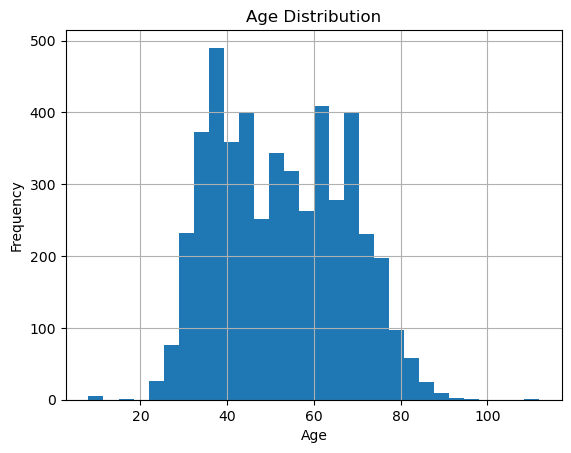

In [16]:
import matplotlib.pyplot as plt

df['age'].dropna().hist(bins=30)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')
plt.show()

In [17]:
df_interests = df.copy()

df_interests['interests'] = df_interests['interests'].str.split(',')
df_interests = df_interests.explode('interests')

In [18]:
df_interests['interests'] = (
    df_interests['interests']
    .str.strip()
    .str.lower()
)

Unique interests

In [20]:
df_interests['interests'].nunique()

60

In [21]:
df_interests['interests'].unique()

array(['energie', 'loterij', 'kranten', 'entertainment', 'winactie',
       'cadeau', 'bladen', 'kansspelen', 'goededoelen', 'acties',
       'unknown', 'kortingen', 'onderzoek', 'auto', 'cx80', 'mkb',
       'verzekering', 'auto inruilen', 'mazda', 'elektrisch',
       'zakelijk rijden', 'audi', 'mazda6e', 'ondernemers', 'dacia',
       'bigevent', 'hybrid', 'mercedes', 'toyota', 'lease', 'windows',
       'bank', 'beleggen', 'finance', 'cx60', 'hr', 'cx5', 'bedrijven',
       'it', 'telcom', 'hypotheek', 'centraal beheer', 'mx30', 'cx30',
       'ios', 'android', 'hyundai', 'linux', nan, 'bedrijfswagen',
       'belastingdienst', 'wetgeving', 'zzp', 'zorg', 'overheid',
       'bezorgmaaltijden', 'horeca', 'os x', 'porsche', 'chrome os',
       'mac os'], dtype=object)

In [22]:
df_interests['interests'].value_counts()

interests
bladen              19382
acties              18990
kranten             18536
winactie            17859
cadeau              17491
kortingen           17436
energie             16884
goededoelen         15515
onderzoek           15224
auto                12766
mazda               12091
unknown             12074
lease               12066
zakelijk rijden     12012
elektrisch          11821
auto inruilen       10336
kansspelen          10224
toyota               9783
audi                 9715
dacia                8440
bigevent             8440
entertainment        8375
finance              8102
bank                 7626
beleggen             7519
verzekering          6966
cx60                 6876
loterij              6827
mkb                  6698
ondernemers          6008
cx80                 5558
hybrid               4867
mazda6e              4601
cx30                 3138
mercedes             2868
bedrijven            2644
mx30                 2609
cx5                  2609
wi

In [23]:
df['postcode'] = (
    df['postcode']
    .astype(str)
    .str.upper()
    .str.replace(' ', '', regex=False)
    .str.extract(r'(\d{4}[A-Z]{0,2})')
)

In [24]:
df['postcode'].sample(50)

17786    3312AC
14538    3035ZB
2086        NaN
15306    3781XB
11462    5301PC
11286    3011HE
12662    7211AX
8899     7202AG
15083    2851ZR
8231     5725AS
15648    1093JL
5714       3990
2685        NaN
2687        NaN
15137    8181JL
15539    8411CN
17510       NaN
2797        NaN
3439        NaN
17589       NaN
13608       NaN
10606      3210
2870        NaN
7486     2993PM
18016       NaN
4220       6051
357         NaN
4901       5015
12003    3434KA
3277        NaN
5538       5482
2670        NaN
429         NaN
17449       NaN
14842       NaN
3716        NaN
4239        NaN
8344     3961HN
4206        NaN
8258       2800
6751     5223KB
6362     3544TM
16107       NaN
141         NaN
7557       2950
7475     1991NL
8755     6822AM
19644    2524KN
18770       NaN
9429     5103BA
Name: postcode, dtype: object

In [25]:
df['city'] = (
    df['city']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace('null', pd.NA)
)

In [26]:
df['city'] = df['city'].replace('nan', pd.NA)

In [27]:
df['interests'] = df['interests'].str.split(',')

In [28]:
type(df['interests'].iloc[0])

list

In [29]:
df['interests'] = df['interests'].apply(
    lambda x: [i.strip().lower() for i in x] if isinstance(x, list) else []
)

In [30]:
df['n_interests'] = df['interests'].apply(len)

In [31]:
df.head()

,id,gender,birth_date,postcode,city,mailings,opens,clicks,interests,age,n_interests
0,5cb9a38136dd1336b9c528d1,male,NaT,NaN,<NA>,"1:668,1:692,1:714,1:733,1:761,1:785,1:804,1:82...","1:879,1:891,1:913,1:935,1:996,1:1031,1:1007,1:...",NaN,"[energie, loterij, kranten, entertainment, win...",NaN,13
1,5cb9a38336dd1336b9c537f3,female,NaT,NaN,<NA>,"1:668,1:692,1:714,1:721,1:729,1:735,1:733,1:75...","1:668,1:692,1:714,1:733,1:753,1:777,1:770,1:75...",NaN,"[auto, loterij, cx80, kranten, mkb, verzekerin...",NaN,30
2,5cb9a38236dd1336b9c52f07,male,NaT,NaN,<NA>,"1:668,1:692,1:714,1:733,1:761,1:785,1:804,1:82...","1:876,1:961,1:1159",NaN,"[auto, kranten, auto inruilen, windows, bladen...",NaN,13
3,5cb9a38236dd1336b9c53694,female,NaT,NaN,<NA>,"1:654,1:668,1:695,1:692,1:706,1:714,1:653,1:73...","1:654,1:706,1:733,1:831,1:866,1:876,1:891,1:91...",NaN,"[cx60, auto, loterij, cx80, kranten, mkb, verz...",NaN,35
4,5cb9a38636dd1336b9c54e48,male,NaT,NaN,<NA>,"1:668,1:692,1:714,1:733,1:760,1:785,1:804,1:82...","1:668,1:692,1:714,1:760,1:785,1:804,1:825,1:84...",NaN,"[auto, kranten, verzekering, winactie, auto in...",NaN,25


# Campaign Analysis 

### Data prep

In [34]:
# inspect (in)valid values in opens and clicks
import re

def classify_value(x):
    if pd.isna(x) or str(x).strip() == '':
        return 'missing'
    
    x = str(x).strip()

    # valid id
    if re.search(r'\b1:\d{3,4}\b', x):
        return 'id_format'
    
    return 'non_id_format'

In [35]:
df['open_type'] = df['opens'].apply(classify_value)
df['click_type'] = df['clicks'].apply(classify_value)

print(df['open_type'].value_counts())
print(df['click_type'].value_counts())

open_type
id_format        17793
non_id_format     2037
missing            170
Name: count, dtype: int64
click_type
missing          19019
non_id_format      787
id_format          194
Name: count, dtype: int64


In [36]:
print(df['mailings'].iloc[0])

# function to extract id from mailings, opens, clicks
def extract_ids(text):
    if pd.isna(text):
        return []
    items = text.split(',')
    ids = []

    for item in items:
        item = item.strip()
        if ':' in item:
            ids.append(int(item.split(':')[1]))
    
    return ids

1:668,1:692,1:714,1:733,1:761,1:785,1:804,1:825,1:846,1:859,1:866,1:873,1:876,1:879,1:892,1:891,1:899,1:874,1:920,1:906,1:913,1:930,1:935,1:958,1:996,1:1031,1:1007,1:1013,1:1040,1:1057,1:1084,1:1093,1:1122,1:1146,1:1159,1:1177,1:1178,1:1231,1:1237,1:1245,1:1281,1:1297,1:1314,1:1340,1:1346,1:1334,1:1362,1:1382,1:1390,1:1398,1:1417


In [37]:
# parse mailings, open, clicks
df['mailing_ids'] = df['mailings'].apply(extract_ids)
df['open_ids'] = df.apply(
    lambda row: extract_ids(row['opens']) if row['open_type'] == 'id_format' else [],
    axis = 1)
df['click_ids'] = df.apply(
    lambda row: extract_ids(row['clicks']) if row['click_type'] == 'id_format' else [],
    axis = 1)

In [38]:
df[['opens', 'open_type', 'open_ids', 'clicks', 'click_type', 'click_ids']].head(26)

,opens,open_type,open_ids,clicks,click_type,click_ids
0,"1:879,1:891,1:913,1:935,1:996,1:1031,1:1007,1:...",id_format,"[879, 891, 913, 935, 996, 1031, 1007, 1013, 10...",NaN,missing,[]
1,"1:668,1:692,1:714,1:733,1:753,1:777,1:770,1:75...",id_format,"[668, 692, 714, 733, 753, 777, 770, 758, 760, ...",NaN,missing,[]
2,"1:876,1:961,1:1159",id_format,"[876, 961, 1159]",NaN,missing,[]
3,"1:654,1:706,1:733,1:831,1:866,1:876,1:891,1:91...",id_format,"[654, 706, 733, 831, 866, 876, 891, 913, 961, ...",NaN,missing,[]
4,"1:668,1:692,1:714,1:760,1:785,1:804,1:825,1:84...",id_format,"[668, 692, 714, 760, 785, 804, 825, 846, 873, ...",NaN,missing,[]
5,"1:876,1:882,1:892,1:874,1:920,1:906,1:961,1:97...",id_format,"[876, 882, 892, 874, 920, 906, 961, 970, 1003,...",NaN,missing,[]
6,"1:714,1:733,1:777,1:770,1:758,1:785,1:803,1:85...",id_format,"[714, 733, 777, 770, 758, 785, 803, 859, 876, ...",NaN,missing,[]
7,"1:876,1:879,1:892,1:891,1:874,1:920,1:906,1:91...",id_format,"[876, 879, 892, 891, 874, 920, 906, 913, 932, ...",NaN,missing,[]
8,"1:668,1:692,1:714,1:760,1:785,1:824,1:846,1:85...",id_format,"[668, 692, 714, 760, 785, 824, 846, 859, 866, ...",NaN,missing,[]
9,"1:761,1:913,1:1381,1:1391",id_format,"[761, 913, 1381, 1391]",NaN,missing,[]


In [39]:
# rename column id
df = df.rename(columns = {'id': 'user_id'})

In [40]:
# explode dataset
df_exploded = df.explode('mailing_ids')
df_exploded = df_exploded.rename(columns = {'mailing_ids': 'mailing_id'})

df_exploded[['user_id', 'mailing_id']].head()

,user_id,mailing_id
0,5cb9a38136dd1336b9c528d1,668
0,5cb9a38136dd1336b9c528d1,692
0,5cb9a38136dd1336b9c528d1,714
0,5cb9a38136dd1336b9c528d1,733
0,5cb9a38136dd1336b9c528d1,761


In [41]:
import numpy as np

In [42]:
# create three state open column: 1 if mailing_id was opened, 0 if not opened, NaN if invalid
def check_open(row):
    if row['open_type'] == 'missing':
        return 0
    
    if row['open_type'] != 'id_format':
        return np.nan
    
    if row['mailing_id'] in row['open_ids']:
        return 1
    else:
        return 0
    
df_exploded['open'] = df_exploded.apply(check_open, axis=1)

df_exploded[['user_id', 'mailing_id', 'open', 'open_ids']].head()

,user_id,mailing_id,open,open_ids
0,5cb9a38136dd1336b9c528d1,668,0.0,"[879, 891, 913, 935, 996, 1031, 1007, 1013, 10..."
0,5cb9a38136dd1336b9c528d1,692,0.0,"[879, 891, 913, 935, 996, 1031, 1007, 1013, 10..."
0,5cb9a38136dd1336b9c528d1,714,0.0,"[879, 891, 913, 935, 996, 1031, 1007, 1013, 10..."
0,5cb9a38136dd1336b9c528d1,733,0.0,"[879, 891, 913, 935, 996, 1031, 1007, 1013, 10..."
0,5cb9a38136dd1336b9c528d1,761,0.0,"[879, 891, 913, 935, 996, 1031, 1007, 1013, 10..."


In [43]:
# create three state click column
def check_click(row):
    if row['click_type'] == 'missing':
        return 0
    
    if row['click_type'] != 'id_format':
        return np.nan
    
    if row['mailing_id'] in row['click_ids']:
        return 1
    else:
        return 0
    
df_exploded['click'] = df_exploded.apply(check_click, axis=1)

df_exploded[['user_id', 'mailing_id', 'open', 'click', 'open_ids', 'click_ids']].head()

,user_id,mailing_id,open,click,open_ids,click_ids
0,5cb9a38136dd1336b9c528d1,668,0.0,0.0,"[879, 891, 913, 935, 996, 1031, 1007, 1013, 10...",[]
0,5cb9a38136dd1336b9c528d1,692,0.0,0.0,"[879, 891, 913, 935, 996, 1031, 1007, 1013, 10...",[]
0,5cb9a38136dd1336b9c528d1,714,0.0,0.0,"[879, 891, 913, 935, 996, 1031, 1007, 1013, 10...",[]
0,5cb9a38136dd1336b9c528d1,733,0.0,0.0,"[879, 891, 913, 935, 996, 1031, 1007, 1013, 10...",[]
0,5cb9a38136dd1336b9c528d1,761,0.0,0.0,"[879, 891, 913, 935, 996, 1031, 1007, 1013, 10...",[]


In [44]:
df_exploded[['user_id', 'mailing_id', 'open', 'click']].head()

,user_id,mailing_id,open,click
0,5cb9a38136dd1336b9c528d1,668,0.0,0.0
0,5cb9a38136dd1336b9c528d1,692,0.0,0.0
0,5cb9a38136dd1336b9c528d1,714,0.0,0.0
0,5cb9a38136dd1336b9c528d1,733,0.0,0.0
0,5cb9a38136dd1336b9c528d1,761,0.0,0.0


In [45]:
print(df_exploded['open'].value_counts(dropna = False))
print(df_exploded['click'].value_counts(dropna = False))

open
1.0    567034
0.0    490510
NaN     98760
Name: count, dtype: int64
click
0.0    1103047
NaN      52062
1.0       1195
Name: count, dtype: int64


In [46]:
# load dataset 2
df2 = pd.read_excel('DATSET 2 UVA lijst mailings.xlsx')

In [47]:
# rename columns
df2 = df2.rename(columns = {
    'ID': 'mailing_id',
    'Mailing': 'mailing_info',
    'Subjectline': 'subject_line',
    'Preheader': 'preheader'
})

In [48]:
# merge dataset 1 and dataset 2
df_final = df_exploded.merge(
    df2,
    on = 'mailing_id',
    how = 'left'
)

In [49]:
print(df_final[['open', 'click']].isna().sum())
print(df_final[['open', 'click']].dtypes)

open     98760
click    52062
dtype: int64
open     float64
click    float64
dtype: object


In [50]:
df_final[['user_id', 'mailing_id', 'open', 'click', 'subject_line']].head()

,user_id,mailing_id,open,click,subject_line
0,5cb9a38136dd1336b9c528d1,668,0.0,0.0,"Lezen, puzzelen, genieten: 4 edities cadeau"
1,5cb9a38136dd1336b9c528d1,692,0.0,0.0,4 weken jouw favoriete krant digitaal voor maa...
2,5cb9a38136dd1336b9c528d1,714,0.0,0.0,Profiteer nu: €300 bonus én vaste energietarieven
3,5cb9a38136dd1336b9c528d1,733,0.0,0.0,Jouw mening is geld waard – start vandaag nog
4,5cb9a38136dd1336b9c528d1,761,0.0,0.0,Speel mee met de ENGIE woordlegger!


In [51]:
# drop unnecessary columns
df_final = df_final.drop(columns = [
    'mailings',
    'opens',
    'clicks',
    'open_ids',
    'click_ids'
])

In [52]:
print(df_final.columns)
df_final.head()

Index(['user_id', 'gender', 'birth_date', 'postcode', 'city', 'interests',
       'age', 'n_interests', 'open_type', 'click_type', 'mailing_id', 'open',
       'click', 'mailing_info', 'subject_line', 'preheader'],
      dtype='object')


,user_id,gender,birth_date,postcode,city,interests,age,n_interests,open_type,click_type,mailing_id,open,click,mailing_info,subject_line,preheader
0,5cb9a38136dd1336b9c528d1,male,NaT,NaN,<NA>,"[energie, loterij, kranten, entertainment, win...",NaN,13,id_format,missing,668,0.0,0.0,2025/04/24 CPX - MM MAX Magazine - 4 gratis nrs,"Lezen, puzzelen, genieten: 4 edities cadeau","Vraag nu aan – geen kosten, geen verplichtingen."
1,5cb9a38136dd1336b9c528d1,male,NaT,NaN,<NA>,"[energie, loterij, kranten, entertainment, win...",NaN,13,id_format,missing,692,0.0,0.0,2025/05/29 DPG 4W1E,4 weken jouw favoriete krant digitaal voor maa...,"Toegang tot AD, de Volkskrant, Trouw en meer v..."
2,5cb9a38136dd1336b9c528d1,male,NaT,NaN,<NA>,"[energie, loterij, kranten, entertainment, win...",NaN,13,id_format,missing,714,0.0,0.0,2025/05/06 CPX - MM - ENGIE BONUS,Profiteer nu: €300 bonus én vaste energietarieven,ENGIE helpt je graag met persoonlijk advies.
3,5cb9a38136dd1336b9c528d1,male,NaT,NaN,<NA>,"[energie, loterij, kranten, entertainment, win...",NaN,13,id_format,missing,733,0.0,0.0,2025/05/14 LIFEPOINTS,Jouw mening is geld waard – start vandaag nog,Verdien punten voor digitale cadeaubonnen zoal...
4,5cb9a38136dd1336b9c528d1,male,NaT,NaN,<NA>,"[energie, loterij, kranten, entertainment, win...",NaN,13,id_format,missing,761,0.0,0.0,2025/05/27 CPX - MM - ENGIE,Speel mee met de ENGIE woordlegger!,"En win een solar powerbank t.w.v. €79,95."


### Overall engagement rates

In [54]:
# subjecline effectiveness (known cases only)
print('Open rate:', df_final['open'].mean())

# content effectiveness (known cases only)
print('Click rate:', df_final['click'].mean())

Open rate: 0.5361800549197008
Click rate: 0.001082190316977619


In [55]:
print('Open unknown %:', df_final['open'].isna().mean())
print('Click unknown %:', df_final['click'].isna().mean())

Open unknown %: 0.08541006517317246
Click unknown %: 0.045024491829138355


In [56]:
# subjectline

result = df_final.groupby(['subject_line', 'preheader']).agg(
    open_mean = ('open', 'mean'),
    click_mean = ('click', 'mean'),
    count_valid = ('open', 'count'),    #excludes NaN
    count_total = ('open', 'size')      #includes everything
)

# top subjectline being sent
result.sort_values('count_valid', ascending = False)[
    ['count_valid', 'count_total', 'open_mean', 'click_mean']
].head(10)

,,count_valid,count_total,open_mean,click_mean
subject_line,preheader,,,,
MAX Magazine én een HEMA verrassing voor jou!,Een jaar lang MAX Magazine én een HEMA giftcard t.w.v. €10.-.,32118,35396,0.496793,0.000383
Ontvang 4 nummers van MAX Magazine cadeau!,Maak kennis met het grootste lifestyle magazine van Nederland.,24601,26489,0.687655,0.000508
Krijg VROUW Glossy of Privé bij De Telegraaf,"Kies uw extraatje en lees De Telegraaf vanaf 5,19 euro per week.",19171,21351,0.644776,0.000778
Wat zit er in Donalds strandtas?,Ontdek het pakket en lees de leukste avonturen deze zomer.,18304,20372,0.000000,0.000000
Meer weten over de impact van Hulphond Nederland?,"Ontvang inspirerende verhalen én maak kans op een cadeaubon van €25,-.",17562,18729,0.638936,0.000337
Welke deal past bij jou deze week?,"Van 4 weken gratis lezen tot een proefabonnement voor 8,-.",17493,19360,0.513405,0.000753
Laatste kans: 4 weken jouw krant voor 1 euro p/w,"Lees o.a. Het AD, de Volkskrant en Trouw. Mis het niet.",17210,19195,0.476351,0.000163
Kies en lees: 4 weken de krant voor 1 euro p/w,Gratis toegang tot digitale artikelen inbegrepen.,16982,18808,0.517195,0.000387
Jouw huidige auto is meer waard dan je denkt,Ontdek het met het Mazda Taxatie Festival.,16534,16974,0.554857,0.003699


# User Engagement Analysis

Explore how user characteristics (gender, age, and interests) relate to engagement metrics

### Overview

#### Data preparation

In [60]:
# open and click rates per user
df_user = df_final.groupby('user_id').agg(
    open_rate = ('open', 'mean'),
    click_rate = ('click', 'mean'),
    total_emails = ('open', 'count')
).reset_index()

# add user info back
df_user = df_user.merge(
    df_final[['user_id', 'gender', 'age', 'interests']].drop_duplicates(subset = 'user_id'),
    on = 'user_id',
    how = 'left'
)

In [61]:
print(df_user['open_rate'].describe())
print(df_user['click_rate'].describe())

count    17963.000000
mean         0.536929
std          0.283799
min          0.000000
25%          0.285714
50%          0.576923
75%          0.789474
max          0.987342
Name: open_rate, dtype: float64
count    19213.000000
mean         0.001209
std          0.016720
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.818182
Name: click_rate, dtype: float64


In [62]:
df_user.isna().sum()

user_id             0
open_rate        2037
click_rate        787
total_emails        0
gender              0
age             15153
interests           0
dtype: int64

In [63]:
print(df_final.groupby('user_id')['open'].apply(
    lambda x: set(x.dropna().unique())
).value_counts())

print(df_final.groupby('user_id')['click'].apply(
    lambda x: set(x.dropna().unique())
).value_counts())

open
{0.0, 1.0}    17793
{}             2037
{0.0}           170
Name: count, dtype: int64
click
{0.0}         19019
{}              787
{0.0, 1.0}      194
Name: count, dtype: int64


##### Insights
- 2037 users (10.19%) have unsuable open data
- 787 users (3.94%) have unsuable click data

In [65]:
# drop users with unsuable engagement data
df_user_clean = df_user.dropna(subset = ['open_rate', 'click_rate'])
df_user_clean.shape

(17286, 7)

In [66]:
print(df_user[df_user['open_rate'].isna() & df_user['click_rate'].notna()].shape)
print(df_user[df_user['click_rate'].isna() & df_user['open_rate'].notna()].shape)

(1927, 7)
(677, 7)


In [67]:
print(df_user_clean['open_rate'].describe())
print(df_user_clean['click_rate'].describe())

count    17286.000000
mean         0.542700
std          0.281576
min          0.000000
25%          0.294118
50%          0.585961
75%          0.791667
max          0.987342
Name: open_rate, dtype: float64
count    17286.000000
mean         0.001187
std          0.015772
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.818182
Name: click_rate, dtype: float64


array([[<Axes: title={'center': 'open_rate'}>,
        <Axes: title={'center': 'click_rate'}>]], dtype=object)

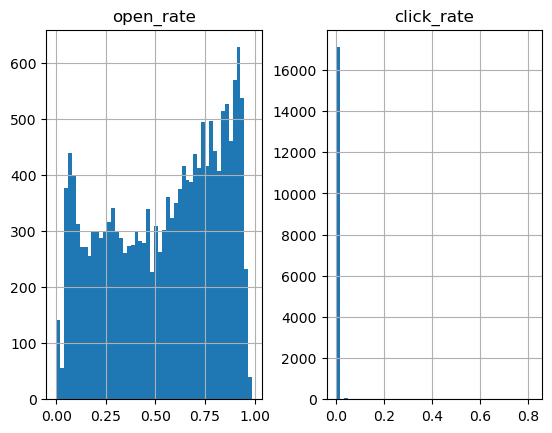

In [68]:
df_user_clean[['open_rate', 'click_rate']].hist(bins=50)

In [69]:
# click rate quantile check
df_user_clean['click_rate'].quantile([
    0.5, 0.75, 0.9, 0.95, 0.99, 0.999])

0.500    0.000000
0.750    0.000000
0.900    0.000000
0.950    0.000000
0.990    0.036145
0.999    0.281250
Name: click_rate, dtype: float64

##### Insights
- 95% of users NEVER click
- Top 1% is small clickers (3.61% click rate)
- Top 0.1% is heavy clickers (28.13% click rate)

In [71]:
# click rate quantile check for users who DO click
df_user_clean[df_user_clean['click_rate'] > 0]['click_rate'].quantile([
    0.5, 0.75, 0.9, 0.95, 0.99])

0.50    0.065217
0.75    0.156076
0.90    0.280903
0.95    0.321452
0.99    0.369069
Name: click_rate, dtype: float64

##### Insights
- Higher click rates mmong people who DO click
- Clickers are quite engaged once they exist
- Click is a rare but strong signal

In [73]:
print('% of users who ever click:', (df_user_clean['click_rate'] > 0).mean())

% of users who ever click: 0.010528751590882795


#### Classify users into engagment segmentation

In [75]:
# threshold for high and low open
open_threshold = df_user_clean['open_rate'].median()        #median because open rate is reasonably spread, but not symmetric

In [76]:
df_user_clean = df_user.dropna(subset=['open_rate', 'click_rate']).copy()

In [77]:
# create user segment

# open segment
df_user_clean['open_segment'] = np.where(
    df_user_clean['open_rate'] >= open_threshold,
    'high_open',
    'low_open')

# click segment
def classify_click(x):
    if x == 0:
        return 'no_click'
    else:
        return 'click'
    
df_user_clean['click_segment'] = df_user_clean['click_rate'].apply(classify_click)

In [78]:
# segment size
df_user_clean.groupby(['open_segment', 'click_segment']).size()

open_segment  click_segment
high_open     click              42
              no_click         8601
low_open      click             140
              no_click         8503
dtype: int64

##### Insights
- Most users frequently open emails
- Only a very small porportion proceed to click
- Users with lower open rates have higher click rates -> selective engagement may indicate stronger intent

### Gender Analysis

In [81]:
df_user_clean.groupby(
    ['open_segment', 'click_segment'])['gender'].value_counts(normalize = True)

open_segment  click_segment  gender
high_open     click          male      0.761905
                             female    0.214286
                             other     0.023810
              no_click       female    0.560865
                             male      0.417393
                             other     0.021742
low_open      click          male      0.514286
                             female    0.485714
              no_click       female    0.559214
                             male      0.420440
                             other     0.020346
Name: proportion, dtype: float64

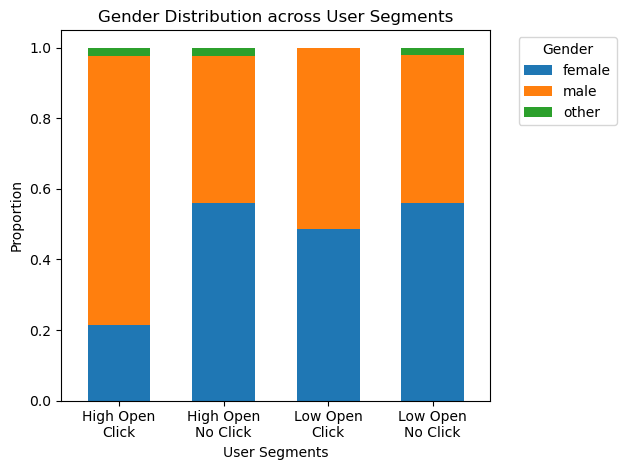

In [82]:
# bar chart

# data prep
gender_distribution = df_user_clean.groupby(
    ['open_segment','click_segment','gender']).size().unstack(fill_value = 0)

# convert to proportions
gender_distribution = gender_distribution.div(gender_distribution.sum(axis = 1), axis = 0)

# plot
gender_distribution.plot(kind = 'bar', stacked = True, width = 0.6)

# rename x labels
plt.xticks(
    ticks=range(len(gender_distribution.index)),
    labels=[
        'High Open\nClick',
        'High Open\nNo Click',
        'Low Open\nClick',
        'Low Open\nNo Click'],
    rotation=0)

plt.title('Gender Distribution across User Segments')
plt.ylabel('Proportion')
plt.xlabel('User Segments')
plt.legend(title='Gender', bbox_to_anchor = (1.05, 1), loc = 'upper left')
plt.tight_layout()
plt.show()

##### Insights
- Male users are more likely to click (strongest in high open high click, with 76% male)
- Female users are more common in non clicking segment
- Conclusion: male users are more likely to convert from opening to clicking

### Age Analysis

In [85]:
df_user_clean.columns

Index(['user_id', 'open_rate', 'click_rate', 'total_emails', 'gender', 'age',
       'interests', 'open_segment', 'click_segment'],
      dtype='object')

In [86]:
# remove unrealistic age
df_user_clean['age_clean'] = df_user_clean['age'].where(
    (df_user_clean['age'] >= 18) &
    (df_user_clean['age'] <= 90))

##### Remark
Unrealistic age values (outside the range 18-90) were removed to ensure data quality

In [88]:
# create age group
df_user_clean['age_group'] = pd.cut(
    df_user_clean['age_clean'],
    bins = [18, 35, 50, 65, 90],
    labels = ['18-35', '35-50', '50-65', '65+'])

# count users per age group
df_user_clean['age_group'].value_counts(normalize = True)

age_group
35-50    0.341901
50-65    0.289525
65+      0.210233
18-35    0.158341
Name: proportion, dtype: float64

#### Engagement rate for age groups

In [90]:
# engagement rate for age groups
df_user_clean.groupby('age_group', observed = True)[['open_rate', 'click_rate']].mean()

,open_rate,click_rate
age_group,,
18-35,0.618223,0.000000
35-50,0.569344,0.000079
50-65,0.465886,0.001669
65+,0.429070,0.003250


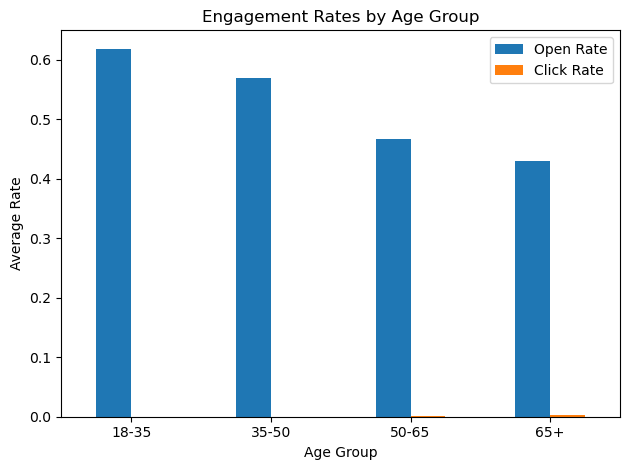

In [91]:
# bar chart

# data prep
age_rates = df_user_clean.groupby('age_group', observed=True)[['open_rate', 'click_rate']].mean()

#plot
age_rates.plot(kind='bar')

plt.title('Engagement Rates by Age Group')
plt.ylabel('Average Rate')
plt.xlabel('Age Group')
plt.xticks(rotation=0)
plt.legend(['Open Rate', 'Click Rate'])
plt.tight_layout()
plt.show()

##### Insights
- Younger users (18-35) have the highest open rate, but rarely click
- Older users (50+) have lower open rate, but more likely to click after opening
- Open rate decrease with age
- Click rate increases with age

#### Age groups vs Engagement segmentation

In [94]:
# age segment size
age_segment = pd.crosstab(
    df_user_clean['age_group'],
    [df_user_clean['open_segment'], df_user_clean['click_segment']],
    normalize = 'index')

age_segment

open_segment  high_open            low_open          
click_segment     click  no_click     click  no_click
age_group                                            
18-35          0.000000  0.627871  0.000000  0.372129
35-50          0.000709  0.521277  0.001418  0.476596
50-65          0.001675  0.381910  0.013400  0.603015
65+            0.008074  0.324106  0.027682  0.640138

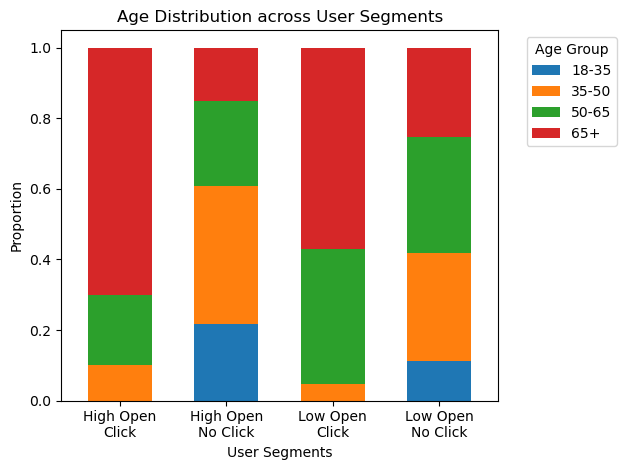

In [95]:
df_user_clean['combined_segment'] = (
    df_user_clean['open_segment'] + ' & ' + df_user_clean['click_segment'])

age_by_segment = pd.crosstab(
    df_user_clean['combined_segment'],
    df_user_clean['age_group'],
    normalize = 'index')

# plot
age_by_segment.plot(kind = 'bar', stacked = True, width = 0.6)

# rename x labels
plt.xticks(
    ticks=range(len(age_by_segment.index)),
    labels=[
        'High Open\nClick',
        'High Open\nNo Click',
        'Low Open\nClick',
        'Low Open\nNo Click'],
    rotation=0)

plt.title('Age Distribution across User Segments')
plt.ylabel('Proportion')
plt.xlabel('User Segments')
plt.legend(title='Age Group', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

##### Insights
- Older users (50+) are more likely to click than younger users
- Younger users (18-35) almost never click (regardless of open level)

### Interest Analysis

#### Explore top interests among users

In [99]:
# explode data with interests
df_interests = df_user_clean.copy()
df_interests = df_interests.explode('interests')

In [100]:
# top user interests
top_interests = df_interests['interests'].value_counts().head(10)
print(top_interests)

interests
bladen         17115
acties         16890
kranten        16738
winactie       16167
cadeau         16060
kortingen      16056
energie        15522
goededoelen    14345
onderzoek      14124
auto           11837
Name: count, dtype: int64


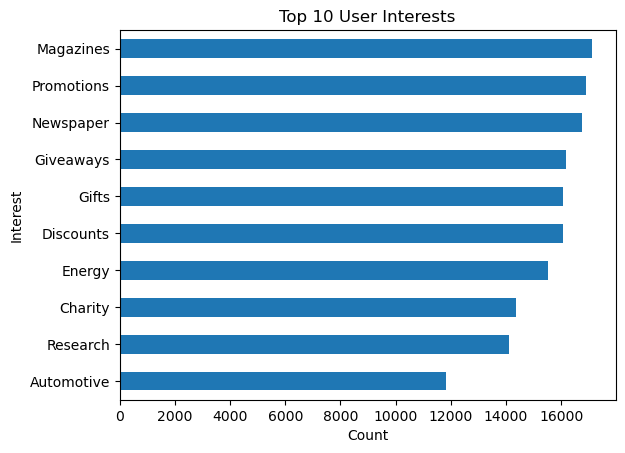

In [101]:
# bar chart

# english translation
interest_map = {
    'bladen': 'Magazines',
    'acties': 'Promotions',
    'kranten': 'Newspaper',
    'winactie': 'Giveaways',
    'cadeau': 'Gifts',
    'kortingen': 'Discounts',
    'energie': 'Energy',
    'goededoelen': 'Charity',
    'onderzoek': 'Research',
    'auto': 'Automotive'}

top_interests_en = top_interests.rename(index = interest_map)

#plot
top_interests_en.plot(kind='barh')
plt.title('Top 10 User Interests')
plt.xlabel('Count')
plt.ylabel('Interest')
plt.gca().invert_yaxis()
plt.show()

##### Insights
- Promotional interests dominate user preferences (promotions, giveaways, gifts, discounts)
- Users show strong interests in informational content (magazines, newspaper, research)
- Commercial topics are also significant (energy and automotive)

#### Explore interests with high engagment rates

In [104]:
# aggregate engagement per interest
interest_engagement = df_interests.groupby('interests').agg(
    open_mean=('open_rate', 'mean'),
    click_mean=('click_rate', 'mean'),
    count=('user_id', 'count'))

interest_engagement.head()

,open_mean,click_mean,count
interests,,,
acties,0.551747,0.001207,16890
android,0.289489,0.001972,1328
audi,0.631697,0.000649,9299
auto,0.574323,0.000851,11837
auto inruilen,0.614763,0.000875,9740


In [105]:
interest_counts = df_interests['interests'].value_counts()
interest_counts.describe()

count       60.000000
mean      6146.933333
std       5542.869329
min          1.000000
25%        723.500000
50%       5429.500000
75%      10089.000000
max      17115.000000
Name: count, dtype: float64

In [106]:
# remove small counts

#threshold for counts
count_threshold = threshold = df_interests['interests'].value_counts().quantile(0.25)
interest_filtered = interest_engagement[
    interest_engagement['count'] >= count_threshold]

##### Remark
Interests with low counts (bottom 25%) to avoid unreliable estimates

In [108]:
# sort interests by open rates
interest_filtered.sort_values('open_mean', ascending=False).head(10)

,open_mean,click_mean,count
interests,,,
bezorgmaaltijden,0.753736,0.000156,1806
mazda6e,0.674259,0.001288,4399
finance,0.661999,0.000579,7736
verzekering,0.660851,0.000921,6583
beleggen,0.659138,0.000777,7154
bank,0.648134,0.000579,7270
mercedes,0.648010,0.001059,2704
hypotheek,0.642729,0.000072,1516
bedrijfswagen,0.637129,0.000845,1459


In [294]:
# sort interests by click rates
interest_filtered.sort_values('click_mean', ascending=False).head(10)

,open_mean,click_mean,count
interests,,,
windows,0.342804,0.002584,2009
android,0.289489,0.001972,1328
mazda6e,0.674259,0.001288,4399
goededoelen,0.566153,0.001282,14345
acties,0.551747,0.001207,16890
bladen,0.547079,0.001195,17115
ondernemers,0.626589,0.001139,5659
mercedes,0.648010,0.001059,2704
bedrijven,0.571938,0.001017,2413


Some overlap between popular and interests with high engagement, but the relationship is not strong or consistent

In [ ]:
# create binary groups for past click rates
df_history['clicked_before'] = (df_history['past_click_rate'] > 0)

In [ ]:
df_history['clicked_before'].value_counts(normalize = True)

In [ ]:
# compare past click rates with current engagement rates
df_history.groupby('clicked_before')[['open', 'click']].mean()

In [ ]:
# emails received before by each bucket
df_history.groupby('clicked_before')['emails_before'].mean()

Insights
- Only 0.76% observations belong to users who had clicked before
- Users with any prior click history show substantially higher future clicks trend
- Prior clickers showed lower overall open rates -> more selective but action-oriented user segment
- Clickers tend to be more exposed to email campaigns but the difference is not huge so click effect is unlikely to be explained solely by exposure count

In [ ]:
print(df_history['emails_before'].describe())
print('\n',df_history['emails_before'].quantile([0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

In [ ]:
# create exposure buckets for number of emails received before 
df_history['exposure_bucket'] = pd.cut(
    df_history['emails_before'],
    bins = [0, 5, 15, 30, 50, 120],
    labels = [
        'very_little',
        'little',
        'moderate',
        'heavy',
        'very_heavy'], include_lowest = True)

In [ ]:
df_history['exposure_bucket'].value_counts(normalize = True)

In [ ]:
# engagement rate
df_history.groupby('exposure_bucket')[['open', 'click']].mean()

Engagement rates by bucket reveal an inverted-U for opens (peaking at moderate exposure) and a monotonic decline for clicks, consistent with an email fatigue effect where heavy exposure reduces both open and click propensity, clicks declining faster than opens.

Insights
- Users with moderate prior exposure (15-30 previously received emails) showed highest open rates
- Very heavily exposed users showed lowest open rate -> email fatigue effect (inbox fatigue), repeated campaign exposure may reduce user response over time
- Click behaviour showed a stronger decline across exposure levels -> deeper email fatigue effect

In [ ]:
df_history.groupby(['past_open_bucket', 'exposure_bucket'])[['open', 'click']].mean()

In [ ]:
# pivot open rates
open_heatmap = df_history.pivot_table(
    values = 'open',
    index = 'past_open_bucket',
    columns = 'exposure_bucket',
    aggfunc = 'mean')

open_heatmap


In [ ]:
# heat map

#relabel rows and columns
open_heatmap = open_heatmap.rename(
    index = {
        'very_low': 'Very Low',
        'low': 'Low',
        'medium': 'Moderate',
        'high': 'High',
        'very_high': 'Very High'},

    columns = {
        'very_little': 'Very Low',
        'little': 'Low',
        'moderate': 'Moderate',
        'heavy': 'High',
        'very_heavy': 'Very High'})

# plot
plt.figure(figsize = (10,6))

sns.heatmap(
    open_heatmap,
    annot = True,
    fmt = ".3f",
    cmap = "YlGnBu"
)

plt.title('Future Open Rate by Historical Opens and Exposure')
plt.ylabel('Historical Open Level')
plt.xlabel('Historical Exposure Level')

plt.show()

Moving down a row (higher past open rate) always produces a much larger jump in future open rate than moving across a column (more exposure). Past behaviour is the stronger signal.

Fatigue effect is visible within every row — within each past open level, the very_heavy exposure column consistently shows the lowest open rate. Even among Very High historical openers, very heavy exposure drops the rate from ~0.909 (moderate exposure) to 0.727. Fatigue exists but is muted for engaged users.

Very High openers with Moderate exposure achieve the highest open rate in the entire matrix: 0.909

Insights
- Past open behaviour is a very strong predictor of future opens (just like in earlier finding)
- Moderate exposure may reinforce engagement rather than immediately causing fatigue (just like in earlier finding)
- Extreme frequent exposure is associated with declining engagement, even among historically active users
- Highly historically engaged users appear more resistant to exposure fatigue

In [ ]:
df_history.groupby(['exposure_bucket', 'clicked_before'])[['open', 'click']].mean()

In [ ]:
# pivot click rates
click_pivot = df_history.pivot_table(
    values = 'click',
    index = 'exposure_bucket',
    columns = 'clicked_before',
    aggfunc = 'mean')

click_pivot

In [ ]:
interaction_plot_click = (df_history.groupby(['exposure_bucket', 'clicked_before'])[['click']].mean().reset_index())

In [ ]:
# line plot

# relabel x axis
""" 
interaction_plot_click['exposure_bucket'] = interaction_plot_click['exposure_bucket'].replace({
    'very_little': 'Very Low',
    'little': 'Low',
    'moderate': 'Moderate',
    'heavy': 'High',
    'very_heavy': 'Very High'})

"""

# relabel x axis
interaction_plot_click['exposure_bucket'] = interaction_plot_click['exposure_bucket'].cat.rename_categories({
    'very_little': 'Very Low',
    'little': 'Low',
    'moderate': 'Moderate',
    'heavy': 'High',
    'very_heavy': 'Very High'})

# relabel hue
interaction_plot_click['clicked_before'] = interaction_plot_click['clicked_before'].replace({
    True: 'Previously Clicked',
    False: 'Never Clicked Before'})

#plot
plt.figure(figsize=(10,6))

sns.lineplot(
    data=interaction_plot_click,
    x='exposure_bucket',
    y='click',
    hue='clicked_before',
    marker='o'
)

plt.title('Future Click Rate by Historical Click Behavior and Exposure')
plt.xlabel('Historical Exposure Level')
plt.ylabel('Future Click Rate')

plt.legend(title = 'Historical Click Behaviour')

plt.show()

Orange line (Previously Clicked): starts at 0.559 and drops steeply — nearly a 10x decline from very_little to very_heavy exposure. The sharpest drop is in the first two steps (very_little → moderate)
Blue line (Never Clicked): hugs zero across the entire x-axis — effectively flat at ~0.0001–0.0008

Insights
- Exposure barely changes anything for users who never clicked before
- Historically engaged clickers are highly sensitive to exposure volume
- Exposure redically compress click behaviour among prior clickers

In [ ]:
# pivot open rates
open_pivot = df_history.pivot_table(
    values = 'open',
    index = 'exposure_bucket',
    columns = 'clicked_before',
    aggfunc = 'mean')

open_pivot

In [ ]:
interaction_plot_open = (df_history.groupby(['exposure_bucket', 'clicked_before'])[['open']].mean().reset_index())

In [ ]:
# line plot

# relabel x axis
interaction_plot_open['exposure_bucket'] = interaction_plot_open['exposure_bucket'].cat.rename_categories({
    'very_little': 'Very Low',
    'little': 'Low',
    'moderate': 'Moderate',
    'heavy': 'High',
    'very_heavy': 'Very High'})

# relabel hue
interaction_plot_open['clicked_before'] = interaction_plot_open['clicked_before'].replace({
    True: 'Previously Clicked',
    False: 'Never Clicked Before'})

#plot
plt.figure(figsize=(10,6))

sns.lineplot(
    data=interaction_plot_open,
    x='exposure_bucket',
    y='open',
    hue='clicked_before',
    marker='o'
)

plt.title('Future Open Rate by Historical Click Behavior and Exposure')
plt.xlabel('Historical Exposure Level')
plt.ylabel('Future Open Rate')

plt.legend(title = 'Historical Click Behaviour')


plt.show()

Blue (Never Clicked): open rate follows the familiar inverted-U from earlier, peaks at moderate exposure (0.605) then falls to 0.445 at very_heavy
Orange (Previously Clicked): starts high (0.646) at very_little but drops sharply and crosses below the non-clickers line by moderate exposure, ending at 0.328 at very_heavy

The crossover between the two lines: prior clickers start as the more engaged group but become the lower-opening group under high exposure, confirming they are a qualitatively different and more fatigue-sensitive segment.

Insights
- Similar but weaker pattern was observed for future opens
- Exposure affects prior clickers much more strongly than historically passive users
- Prior clickers showed substantially lower open rates under heavier exposure levels

In [ ]:
df_history.groupby(['past_open_bucket', 'clicked_before'])[['open', 'click']].mean()

In [ ]:
# create binary open groups (high/low past opens)
df_history['open_behaviour'] = np.where(
    df_history['past_open_rate'] >= df_history['past_open_rate'].median(),      # median as threshold
    'High Historical Opens',
    'Low Historical Opens')

In [ ]:
df_history['open_behaviour'].value_counts(normalize = True)

In [ ]:
# create behavioural groups based on open groups and click groups
conditions = [
    (df_history['open_behaviour'] == 'High Historical Opens') &
    (df_history['clicked_before'] == False),

    (df_history['open_behaviour'] == 'High Historical Opens') &
    (df_history['clicked_before'] == True),

    (df_history['open_behaviour'] == 'Low Historical Opens') &
    (df_history['clicked_before'] == False),

    (df_history['open_behaviour'] == 'Low Historical Opens') &
    (df_history['clicked_before'] == True)]

# group names
choices = [
    'Habitual Openers',         # high past opens, never clicked
    'Highly Engaged Users',     # high past opens, clicked before
    'Disengaged Users',         # low past opens, never clicked
    'Selective Users']          # low past opens, clicked before

df_history['engagement_group'] = np.select(conditions, choices, default = 'Other')

In [ ]:
df_history.groupby('engagement_group')[['open', 'click']].mean().sort_values('click', ascending = False)

In [ ]:
df_history['engagement_group'].value_counts(normalize = True)

Disengaged Users: 54% — the majority of interactions come from the lowest-value segment

Habitual Openers: 45% — high open rates but almost zero click value

Selective Users: 0.53% — tiny but punching far above their weight in clicks

Highly Engaged Users: 0.22% — the rarest and most valuable segment

The two highest-click segments together represent less than 1% of all interactions, yet they are the primary drivers of click revenue.

## Dataset with time

 ### Dataset

In [189]:
#check what columns exist
df_final.columns.tolist()

['user_id',
 'gender',
 'birth_date',
 'postcode',
 'city',
 'interests',
 'age',
 'n_interests',
 'open_type',
 'click_type',
 'mailing_id',
 'open',
 'click',
 'mailing_info',
 'subject_line',
 'preheader']

In [191]:
df_time = pd.read_excel('UVA Robin .xlsx') 

In [193]:
print(df_time.shape)
print(df_time.columns.tolist())

(1400, 11)
['Unnamed: 0', 'Subjectline', 'Mail ID ', 'Dag', 'Datum', 'Klant / bureau', 'Campagnenaam', 'Time stamp ', 'openInterst / clickInterest ', 'Mail content ', 'Unnamed: 10']


In [195]:
print(df_time.head(5))

  Unnamed: 0                       Subjectline Mail ID         Dag  \
0       ntvx                               NaN     1417  Donderdag   
1        NaN  Wat zit er in Donalds strandtas?     1419        NaN   
2        NaN                               NaN      NaN        NaN   
3        NaN                               NaN      NaN        NaN   
4       ntvx                               NaN     1418  Donderdag   

                 Datum Klant / bureau                Campagnenaam  \
0  2026-04-23 00:00:00            CPX  Donald Duck + Strandpakket   
1                  NaN            NaN                         NaN   
2                  NaN            NaN                         NaN   
3                  NaN            NaN                         NaN   
4  2026-04-23 00:00:00            CRS  Donald Duck + Strandpakket   

                                         Time stamp   \
0                                           -Akkoord   
1      Subjectline: Wat zit er in Donalds strandtas?

In [197]:
df_time.columns = ['client', 'subject_line', 'mailing_id', 'day_of_week',
    'send_date', 'client_bureau', 'campaign_name',
    'log_field', 'target_interests', 'mail_content', 'extra']
df_time.head(5)

,client,subject_line,mailing_id,day_of_week,send_date,client_bureau,campaign_name,log_field,target_interests,mail_content,extra
0,ntvx,NaN,1417,Donderdag,2026-04-23 00:00:00,CPX,Donald Duck + Strandpakket,-Akkoord,"bladen, cadeaux",NaN,NaN
1,NaN,Wat zit er in Donalds strandtas?,1419,NaN,NaN,NaN,NaN,Subjectline: Wat zit er in Donalds strandtas?,NaN,https://mail.omg.nl/x/?S7Y1.J9ra2hiaPm.CMjMyU_...,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Pre-header: Ontdek het pakket en lees de leuks...,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,260422 - CPX - CPX Donald Duck + Strandpakket ...,NaN,NaN,NaN
4,ntvx,NaN,1418,Donderdag,2026-04-23 00:00:00,CRS,Donald Duck + Strandpakket,-Akkoord,"bladen, cadeaux",https://mail.omg.nl/x/?S7Y1.J9ra2hiaPm.CMjMyU_...,NaN


In [199]:
#for each mailing_id, find the row containing 'adressen' and extract from there
def extract_from_log(df_raw, mailing_col='mailing_id'):
    results = []
    df_raw['mailing_id_filled'] = df_raw['mailing_id'].ffill()
    
    for mid, group in df_raw.groupby('mailing_id_filled'):
        log_rows = group[group['log_field'].str.contains('adressen', na=False, case=False)]
        send_hour = None
        audience_size = None
        
        for _, row in log_rows.iterrows():
            log = str(row['log_field'])
            hour_m = re.search(r'\b(\d{1,2})u(?:ur)?\b', log)
            size_m = re.search(r'([\d\.]+)\s+adressen', log, re.IGNORECASE)
            if hour_m:
                send_hour = int(hour_m.group(1))
            if size_m:
                try:
                    audience_size = int(size_m.group(1).replace('.', ''))
                except ValueError:
                    pass
        
        results.append({'mailing_id': mid, 'send_hour': send_hour, 'audience_size': audience_size})
    
    return pd.DataFrame(results)

df_log_info = extract_from_log(df_raw=df_time)

In [494]:
df_log_info

,mailing_id,send_hour,audience_size
0,641,19.0,18243.0
1,646,19.0,17343.0
2,647,19.0,65000.0
3,653,16.0,26922.0
4,654,16.0,45000.0
...,...,...,...
186,1419,19.0,247426.0
187,Na het inplannen van elke verzending moet je p...,NaN,NaN
188,X,16.0,8000.0
189,x,16.0,20000.0


Assuming that every sub-row belongs to the campaign block directly above it, so it shares the same date and day of week.

In [201]:
# Forward fill day_of_week and send_date to fill gaps
df_time_filled = df_time.copy()
df_time_filled['day_of_week'] = df_time_filled['day_of_week'].ffill()
df_time_filled['send_date'] = df_time_filled['send_date'].ffill()

#keep only rows with valid numeric mailing_id
df_time_filled = df_time_filled[
    df_time_filled['mailing_id'].astype(str).str.match(r'^\d+$')
].copy()
df_time_filled['mailing_id'] = df_time_filled['mailing_id'].astype(int)

# Keep one row per mailing_id (first occurrence)
df_time_clean = df_time_filled.drop_duplicates(subset='mailing_id', keep='first').copy()

# translate Dutch day names to English
day_map = {
    'Maandag': 'Monday', 'Dinsdag': 'Tuesday', 'Woensdag': 'Wednesday',
    'Donderdag': 'Thursday', 'Vrijdag': 'Friday',
    'Zaterdag': 'Saturday', 'Zondag': 'Sunday'
}
df_time_clean['day_of_week'] = df_time_clean['day_of_week'].map(day_map).fillna(df_time_clean['day_of_week'])

print(f"Shape: {df_time_clean.shape}")

Shape: (186, 12)


In [203]:
print(f"Unique mailing IDs: {df_time_clean['mailing_id'].nunique()}")
print('\n', df_time_clean['day_of_week'].value_counts(dropna=False))
print('\n', df_time_clean[['mailing_id', 'day_of_week', 'send_date']].head(10))

Unique mailing IDs: 186

 day_of_week
Thursday     84
Tuesday      51
Wednesday    35
Friday        9
Monday        3
Sunday        2
Saturday      2
Name: count, dtype: int64

     mailing_id day_of_week            send_date
0         1417    Thursday  2026-04-23 00:00:00
1         1419    Thursday  2026-04-23 00:00:00
4         1418    Thursday  2026-04-23 00:00:00
12        1411     Tuesday  2026-04-21 00:00:00
16        1408    Thursday  2026-04-16 00:00:00
19        1398    Thursday  2026-04-16 00:00:00
20        1399    Thursday  2026-04-16 00:00:00
29        1403     Tuesday  2026-04-14 00:00:00
33        1365     Tuesday  2026-04-07 00:00:00
37        1390   Wednesday  2026-04-08 00:00:00


#### Merge

In [205]:
#clean df_log_info and df_time_clean
df_log_info_clean = df_log_info[
    df_log_info['mailing_id'].astype(str).str.match(r'^\d+$')].copy()

df_log_info_clean['mailing_id'] = df_log_info_clean['mailing_id'].astype(int)

In [207]:
#merge
df_time_clean = df_time_clean.merge(df_log_info_clean, on='mailing_id', how='left')

print(f"send_hour NaNs: {df_time_clean['send_hour'].isna().sum()} out of {len(df_time_clean)}")
print(df_time_clean[['mailing_id', 'day_of_week', 'send_date', 'send_hour', 'audience_size']].head(10))

send_hour NaNs: 37 out of 186
   mailing_id day_of_week            send_date  send_hour  audience_size
0        1417    Thursday  2026-04-23 00:00:00        NaN            NaN
1        1419    Thursday  2026-04-23 00:00:00       19.0       247426.0
2        1418    Thursday  2026-04-23 00:00:00        NaN            NaN
3        1411     Tuesday  2026-04-21 00:00:00       16.0        25500.0
4        1408    Thursday  2026-04-16 00:00:00        NaN            NaN
5        1398    Thursday  2026-04-16 00:00:00        NaN            NaN
6        1399    Thursday  2026-04-16 00:00:00       19.0        83815.0
7        1403     Tuesday  2026-04-14 00:00:00       16.0         2000.0
8        1365     Tuesday  2026-04-07 00:00:00       16.0        23567.0
9        1390   Wednesday  2026-04-08 00:00:00        NaN       169385.0


In [209]:
#merge into df_final
df_final_time = df_final.merge(
    df_time_clean[['mailing_id', 'day_of_week', 'send_date', 'send_hour', 'audience_size']],
    on='mailing_id',
    how='left'
)

df_final_time = df_final_time.merge(
    df_time_clean[['mailing_id', 'client_bureau', 'campaign_name']],
    on='mailing_id', how='left'
)
print(f"Shape: {df_final_time.shape}")

Shape: (1156304, 22)


In [210]:
print(f"day_of_week NaNs: {df_final_time['day_of_week'].isna().sum()}")
print(f"send_hour NaNs: {df_final_time['send_hour'].isna().sum()}")
print(f"Rows WITH day_of_week: {df_final_time['day_of_week'].notna().sum()}")

day_of_week NaNs: 339593
send_hour NaNs: 578454
Rows WITH day_of_week: 816711


In [213]:
print(df_final_time['day_of_week'].value_counts(dropna=False))

day_of_week
Thursday     368358
NaN          339593
Wednesday    267562
Tuesday      117932
Friday        36521
Sunday        13322
Saturday      11418
Monday         1598
Name: count, dtype: int64


In [215]:
#Coverage
timed_rows = df_final_time['day_of_week'].notna().mean() * 100
n_timed_mail = df_final_time[df_final_time['day_of_week'].notna()]['mailing_id'].nunique()

print(f"df_final unique mailings    : {df_final['mailing_id'].nunique()}")
print(f"df_time_clean unique mailings: {df_time_clean['mailing_id'].nunique()}")
print(f"Mailings matched            : {n_timed_mail}")
print(f"Row coverage (open/click)   : {timed_rows:.1f}%")

df_final_time[['user_id', 'mailing_id', 'open', 'click',
               'day_of_week', 'send_hour', 'audience_size']].head(10)

df_final unique mailings    : 274
df_time_clean unique mailings: 186
Mailings matched            : 168
Row coverage (open/click)   : 70.6%


,user_id,mailing_id,open,click,day_of_week,send_hour,audience_size
0,5cb9a38136dd1336b9c528d1,668,0.0,0.0,Friday,NaN,186527.0
1,5cb9a38136dd1336b9c528d1,692,0.0,0.0,Wednesday,19.0,243103.0
2,5cb9a38136dd1336b9c528d1,714,0.0,0.0,Wednesday,19.0,150575.0
3,5cb9a38136dd1336b9c528d1,733,0.0,0.0,Wednesday,19.0,139736.0
4,5cb9a38136dd1336b9c528d1,761,0.0,0.0,Wednesday,19.0,158657.0
5,5cb9a38136dd1336b9c528d1,785,0.0,0.0,Wednesday,19.0,205235.0
6,5cb9a38136dd1336b9c528d1,804,0.0,0.0,Wednesday,NaN,NaN
7,5cb9a38136dd1336b9c528d1,825,0.0,0.0,Friday,7.0,132123.0
8,5cb9a38136dd1336b9c528d1,846,0.0,0.0,Wednesday,19.0,99664.0
9,5cb9a38136dd1336b9c528d1,859,0.0,0.0,NaN,NaN,NaN


In [217]:
total = len(df_final_time)
dow_coverage = df_final_time['day_of_week'].notna().sum()
hour_coverage = df_final_time['send_hour'].notna().sum()
date_coverage = df_final_time['send_date'].notna().sum()

print(f"Total rows          : {total:,}")
print(f"day_of_week coverage: {dow_coverage:,} ({dow_coverage/total*100:.1f}%)")
print(f"send_hour coverage  : {hour_coverage:,} ({hour_coverage/total*100:.1f}%)")
print(f"send_date coverage  : {date_coverage:,} ({date_coverage/total*100:.1f}%)")

Total rows          : 1,156,304
day_of_week coverage: 816,711 (70.6%)
send_hour coverage  : 577,850 (50.0%)
send_date coverage  : 816,711 (70.6%)


Temporal data was available for 186 out of 274 unique campaigns, covering 70% of user-mailing interactions. Analysis is conducted on this subset. Older campaigns (mailing IDs < 1334) lack temporal metadata and are excluded from this section. Findings should be interpreted as indicative rather than exhaustive.

In [219]:
print(df_final_time[['open', 'click']].isna().sum())

open     98760
click    52062
dtype: int64


#### Day of Week

In [ ]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

day_stats = (
    df_final_time.dropna(subset=['day_of_week', 'open', 'click'])
    .groupby('day_of_week')
    .agg(open_rate=('open', 'mean'),
         click_rate=('click', 'mean'),
         n_records=('open', 'count'))
    .reindex([d for d in day_order if d in df_final_time['day_of_week'].dropna().unique()])
    .reset_index()
)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, metric, label, color in zip(
    axes,
    ['open_rate', 'click_rate'],
    ['Open Rate', 'Click Rate'],
    ['steelblue', 'coral'],
):
    ax.bar(day_stats['day_of_week'], day_stats[metric] * 100, color=color, alpha=0.85)
    ax.set_title(f'{label} by Day of Week')
    ax.set_xlabel('Day of Week')
    ax.set_ylabel(f'{label} (%)')
    ax.tick_params(axis='x', rotation=30)
    
    # Put n= labels INSIDE the bars
    for i, (_, row) in enumerate(day_stats.iterrows()):
        ax.text(i, row[metric] * 100 * 0.5,  # halfway up the bar
                f"n={row['n_records']:,}", 
                ha='center', va='center',
                fontsize=7, color='white', fontweight='bold')
    
    # Add 10% headroom above tallest bar
    ax.set_ylim(0, day_stats[metric].max() * 100 * 1.1)

plt.tight_layout()
plt.show()

print(day_stats[['day_of_week', 'open_rate', 'click_rate', 'n_records']].to_string(index=False))

Open Rate insights:

Saturday has the highest open rate (68%) — but only 9,963 rows, so treat cautiously. Could reflect a selection effect — fewer emails sent on Saturdays, so those that are sent may be more targeted

Tuesday, Wednesday, Thursday are very similar (~53-54%) — these are the core weekday send days with the highest volume and most reliable estimates

Monday is the lowest (14.5%) — but only 1,245 rows, making it statistically unreliable

Sunday is notably lower (35%) than Saturday despite similar volume — suggests weekend engagement is inconsistent

Click Rate insights:

Sunday has the highest click rate (0.31%) — interesting contrast with its lower open rate, suggesting users who open on Sunday are more action-oriented

Friday also performs well for clicks (0.17%) — despite moderate open rates

Wednesday has the lowest click rate (0.07%) — despite being the second most common send day

Thursday dominates volume (322k rows) but has mediocre click performance (0.09%)

#### Send Hour

In [ ]:
hour_stats = (
    df_final_time.dropna(subset=['send_hour', 'open', 'click'])
    .groupby('send_hour')
    .agg(open_rate=('open', 'mean'), click_rate=('click', 'mean'),
         n_mailings=('mailing_id', 'nunique'), n_records=('open', 'count'))
    .reset_index()
    .sort_values('send_hour')
)
hour_stats['send_hour'] = hour_stats['send_hour'].astype(int)

In [ ]:
# Remove impossible hours
hour_stats_clean = hour_stats[hour_stats['send_hour'] <= 23].copy()
print(hour_stats_clean[['send_hour', 'open_rate', 'click_rate', 'n_mailings', 'n_records']])

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, metric, label, color in zip(
    axes,
    ['open_rate', 'click_rate'],
    ['Open Rate', 'Click Rate'],
    ['steelblue', 'coral'],
):
    x = range(len(hour_stats_clean))  # use index positions instead of raw hours
    ax.bar(x, hour_stats_clean[metric] * 100, color=color, alpha=0.85, width=0.6)
    ax.set_title(f'{label} by Send Hour')
    ax.set_xlabel('Send Hour (24h)')
    ax.set_ylabel(f'{label} (%)')
    ax.set_xticks(x)
    ax.set_xticklabels(hour_stats_clean['send_hour'].astype(int), rotation=45)
    ax.set_ylim(0, hour_stats_clean[metric].max() * 100 * 1.15)
    
    # n labels inside bars
    for i, (_, row) in enumerate(hour_stats_clean.iterrows()):
        ax.text(i, row[metric] * 100 * 0.5,
                f"n={int(row['n_mailings'])}",
                ha='center', va='center',
                fontsize=7, color='white', fontweight='bold')

plt.tight_layout()
plt.show()
print(hour_stats_clean[['send_hour', 'open_rate', 'click_rate', 'n_mailings', 'n_records']].to_string(index=False))

Send hour analysis is limited to hours with sufficient campaign volume.
Only hours 16 and 19 are statistically reliable (n=63 and n=41 campaigns). Other hours have too few campaigns for meaningful conclusions.

Full send-time optimisation requires broader experimentation across hours. (OMG almost exclusively sends at 16:00 and 19:00, making it impossible to properly evaluate other time slots)

#### Month Analysis

In [ ]:
# Extract month and year from send_date
df_final_time['send_date'] = pd.to_datetime(df_final_time['send_date'])
df_final_time['month'] = df_final_time['send_date'].dt.month
df_final_time['year'] = df_final_time['send_date'].dt.year
df_final_time['month_year'] = df_final_time['send_date'].dt.to_period('M')

# Monthly engagement
monthly_stats = (
    df_final_time.dropna(subset=['month_year', 'open', 'click'])
    .groupby('month_year')
    .agg(open_rate=('open', 'mean'), click_rate=('click', 'mean'),
         n_mailings=('mailing_id', 'nunique'), n_records=('open', 'count'))
    .reset_index()
    .sort_values('month_year')
)

print(monthly_stats.to_string(index=False))

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

x = range(len(monthly_stats))
x_labels = monthly_stats['month_year'].astype(str)

for ax, metric, label, color in zip(
    axes,
    ['open_rate', 'click_rate'],
    ['Open Rate', 'Click Rate'],
    ['steelblue', 'coral'],
):
    ax.plot(x, monthly_stats[metric] * 100, color=color, marker='o', linewidth=2)
    ax.fill_between(x, monthly_stats[metric] * 100, alpha=0.2, color=color)
    ax.set_title(f'{label} over Time (Monthly)')
    ax.set_ylabel(f'{label} (%)')
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=45)
    ax.set_ylim(0, monthly_stats[metric].max() * 100 * 1.15)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Add n= labels
    for i, (_, row) in enumerate(monthly_stats.iterrows()):
        ax.text(i, row[metric] * 100 + row[metric] * 100 * 0.05,
                f"n={int(row['n_mailings'])}",
                ha='center', fontsize=7)

plt.tight_layout()
plt.show()

Monthly engagement trends show a clear seasonal pattern for opens — peaking in December 2025 and declining sharply in early 2026.

Click rates are more volatile, peaking in Oct-Nov 2025 and Feb 2026.

The decline in both metrics in 2026 warrants further investigation.

Note: months with fewer than 6 campaigns should be interpreted cautiously.

In [ ]:
#Groups campaigns into 5 meaningful audience size buckets
size_bins = [0, 10_000, 50_000, 100_000, 300_000, float('inf')]
size_labels = ['<10k', '10k–50k', '50k–100k', '100k–300k', '>300k']
pd.cut(df_final_time['audience_size'], bins=size_bins, labels=size_labels)

In [ ]:
df_final_time['audience_bucket'] = pd.cut(
    df_final_time['audience_size'],
    bins=[0, 10_000, 50_000, 100_000, 300_000, float('inf')],
    labels=['<10k', '10k-50k', '50k-100k', '100k-300k', '>300k']
)

size_stats = (
    df_final_time.dropna(subset=['audience_bucket', 'open', 'click'])
    .groupby('audience_bucket', observed=True)
    .agg(open_rate=('open', 'mean'), click_rate=('click', 'mean'),
         n_mailings=('mailing_id', 'nunique'), n_records=('open', 'count'))
    .reset_index()
)

print(size_stats)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#2ecc71', '#9b59b6'] 

for ax, metric, label, color in zip(
    axes,
    ['open_rate', 'click_rate'],
    ['Open Rate', 'Click Rate'],
    colors,
):
    x = range(len(size_stats))
    ax.bar(x, size_stats[metric] * 100, color=color, alpha=0.85)
    ax.set_title(f'{label} by Audience Size')
    ax.set_xlabel('Audience Size')
    ax.set_ylabel(f'{label} (%)')
    ax.set_xticks(x)
    ax.set_xticklabels(size_stats['audience_bucket'].astype(str), rotation=30)
    ax.set_ylim(0, size_stats[metric].max() * 100 * 1.15)
    
    # Labels inside bars
    for i, (_, row) in enumerate(size_stats.iterrows()):
        ax.text(i, row[metric] * 100 * 0.5,
                f"n={int(row['n_mailings'])}",
                ha='center', va='center',
                fontsize=9, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

Audience size has negligible effect on open rates but shows meaningful variation in click rates. Very large campaigns (100k-300k recipients) achieve the lowest click rates, suggesting that broader targeting reduces content-audience fit and post-open conversion.

The non-monotonic pattern may reflect confounding with campaign type; small campaigns tend to be more targeted by design.

In [ ]:
#check what columns exist
df_final_time.columns.tolist()

In [ ]:
#main_topic
df_final_time = df_final_time.merge(
    df_final_topic[['mailing_id', 'main_topic']].drop_duplicates(subset='mailing_id'),
    on='mailing_id',
    how='left')

print(df_final_time['main_topic'].value_counts(dropna=False))

In [ ]:
#rows with day_of_week and main_topic
df_topic_time = df_final_time.dropna(subset=['day_of_week', 'main_topic']).copy()
df_topic_time = df_topic_time[df_topic_time['main_topic'] != 'Missing']

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

#Open rate by day x topic
topic_day_open = (
    df_topic_time.groupby(['main_topic', 'day_of_week'])['open']
    .mean()
    .unstack('day_of_week')
    .reindex(columns=[d for d in day_order if d in df_topic_time['day_of_week'].unique()]))

print(topic_day_open.round(3))

In [ ]:
plt.figure(figsize=(12, 6))
sns.heatmap(
    topic_day_open,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu',
    linewidths=0.5)

plt.title('Open Rate by Topic and Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Topic')
plt.tight_layout()
plt.show()

Topic and send day interact meaningfully — the optimal send day differs by topic. This directly supports the case for personalised send-time recommendations rather than one-size-fits-all scheduling.

Lottery & Games peaks on Friday (0.75), Media & Publishing on Friday/Saturday, while Business content is day-insensitive.

Note: many cells have limited campaign coverage — findings are indicative and require more data to confirm.

In [ ]:
# Click rate by day x topic
topic_day_click = (
    df_topic_time.groupby(['main_topic', 'day_of_week'])['click']
    .mean()
    .unstack('day_of_week')
    .reindex(columns=[d for d in day_order if d in df_topic_time['day_of_week'].unique()])
)

print(topic_day_click.round(4))

In [ ]:
plt.figure(figsize=(12, 6))
sns.heatmap(
    topic_day_click,
    annot=True,
    fmt='.4f',
    cmap='YlOrRd',
    linewidths=0.5,
    mask=topic_day_click.isna()
)
plt.title('Click Rate by Topic and Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Topic')
plt.tight_layout()
plt.show()

In [ ]:
#campaigns behind Lottery & Games Friday
df_topic_time[
    (df_topic_time['main_topic'] == 'Lottery & Games') & 
    (df_topic_time['day_of_week'] == 'Friday')
]['mailing_id'].nunique()

Lottery & Games Friday click rate (0.1360) is based on a single campaign and should not be interpreted as a meaningful pattern. It is a statistical artefact of extremely low sample size.

The click rate heatmap overall has very limited reliability due to:
1. Rarity of click events across all topic-day combinations
2. Most cells backed by only 1-3 campaigns
3. Charity & Social Impact (Thursday) and Finance & Investment (Thursday) show the most consistent click performance but still require more data to confirm.

# Content-Based Recommendation: Biterm Topic Model (BTM)

This section builds a content-based recommendation system using Biterm Topic Modelling (BTM).
BTM is designed for short texts and learns topics from co-occurring word pairs (biterms) pooled
across the entire corpus.  Campaign texts (subject line) and user interest
pseudo-documents share the same vocabulary and topic space, enabling cosine-similarity matching.

In [221]:
import numpy as np
import pandas as pd
import re
import bitermplus as btm
from sklearn.metrics.pairwise import cosine_similarity
from itertools import combinations
from scipy.sparse import issparse
from collections import defaultdict
import math
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
import spacy
from nltk.stem.snowball import SnowballStemmer
import warnings
warnings.filterwarnings('ignore')

In [222]:
# Dutch stopwords + domain noise
dutch_stopwords = set(stopwords.words('dutch'))
domain_stopwords = {
    'de', 'het', 'een', 'en', 'van', 'in', 'op', 'te', 'dat', 'is', 'zijn', 'kan',
    'voor', 'met', 'aan', 'er', 'maar', 'om', 'je', 'jij', 'jouw', 'jou', 'uw', 'hij', 'hun', 'ze',
    'we', 'zij', 'zelf', 'ook', 'als', 'dan', 'bij', 'uit', 'door', 'nu', 'al',
    'nog', 'wel', 'niet', 'geen', 'meer', 'kan', 'dit', 'die', 'naar', 'bent',
    'zo', 'over', 'of', 'want', 'hoe', 'wat', 'wie', 'waar', 'wanneer',
    'heeft', 'hebben', 'worden', 'wordt', 'waren', 'wij', 'ons', 'onze',
    'mijn', 'mee', 'tot', 'dus', 'echt', 'elke', 'elk', 'alle', 'alles',
    'kun', 'kunt', 'zal', 'zult', 'zou', 'zouden', 'had', 'toch', 'zeker',
    'altijd', 'nooit', 'soms', 'pas', 'juist', 'heel', 'erg', 'zeer', 'eigen',
    'vrij', 'bijna', 'steeds', 'direct', 'nl', 'www', 'com', 'unknown', 'iedereen', 'zich', 'ervaar',
      # Generic campaign call-to-action words (appear in every topic)
    'ontdek', 'maak', 'begin', 'kies', 'vind', 'ontvang', 'helpt', 'doe', 'voel',
    'ontmoet', 'probeer', 'vraag', 'meld', 'speel', 'krijg', 'genieten', 'doelen', 'verhalen', 'spaar', 'welkom',
    'weten', 'vullen', 'regelen', 'lezen', 'kiezen', 'vinden', 'speel', 'werk', 
    # Generic marketing words
    'nieuwe', 'beste', 'best', 'gratis', 'extra', 'tijdelijk', 'exclusief', 'speciaal', 'uniek', 'groot', 'klein', 'uniek', 'werk',
    'snel', 'makkelijk', 'sneller', 'toegang', 'vaste', 'vast', 'nieuwe', 'nieuw', 'nieuwste', 'grote', 'kleine', 'blijf',
    # Generic time/quantity words
    'jaar', 'weken', 'dag', 'dagen', 'maand', 'euro', 'per', 'vanaf', 'tot', 'november',
    'eerste', 'laatste', 'lang', 'kort', 'vandaag', 'week', 'jaren', 'nov', 'december', 'dec', 'juni', 'juli', 'mei'
    # Generic action/result words  
    'kans', 'voordeel', 'meer', 'beter', 'samen', 'weer', 'goed', 'goede',
    'mooi', 'leuk', 'fijn', 'handig', 'slim', 'sterk',
    # Technical/tracking noise
    #'unknown', 'default', 'cpx', 'crs', 'rno', 'rnc', 'uitrol',
    #'fase', 'campagne', 'awareness', 'reminder', 'clicks', 'non',
    # Generic Dutch email words
    'nederland', 'amsterdam', 'via', 'deze', 'die', 'tussen', 'naar', 'binnen',
    'voornaam', 'mis', 'deel', 'zonder', 'graag', 'start', 'rotterdam', 'ontvang', 'laat'
}

all_stopwords = dutch_stopwords | domain_stopwords

nlp = spacy.load('nl_core_news_sm')
stemmer = SnowballStemmer('dutch')

# ── Preprocessing: tokenize, stopwords, lemmatize, stem ──────────────────────
def preprocess(text):
    if not isinstance(text, str) or not text.strip():
        return ''
    
    # 1. Lowercase
    text = text.lower()
    
    # 2. Remove non-alphabetic characters
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # 3. Tokenize + lemmatize + stopword removal via spacy
    doc = nlp(text)
    tokens = [
        token.lemma_ for token in doc
        if not token.is_stop
        and not token.is_punct
        and not token.is_space
        and token.text not in all_stopwords
        and token.lemma_ not in all_stopwords
        and len(token.lemma_) > 2
    ]
    
    return ' '.join(tokens)

In [223]:
campaign_docs = (
    df_final[['mailing_id', 'subject_line']]
    .drop_duplicates(subset='subject_line')  # deduplicate on subject line
    .drop_duplicates(subset='mailing_id')
    .copy()
)

campaign_docs['text'] = campaign_docs['subject_line'].fillna('').apply(preprocess)
campaign_docs = campaign_docs[campaign_docs['text'].str.strip() != ''].reset_index(drop=True)

# Also deduplicate on processed text — removes near-identical campaigns
campaign_docs = campaign_docs.drop_duplicates(subset='text').reset_index(drop=True)

campaign_texts = campaign_docs['text'].tolist()

print(f'Campaign documents after deduplication: {len(campaign_docs)}')
print(f'Removed: {271 - len(campaign_docs)} duplicate/near-duplicate campaigns')

Campaign documents after deduplication: 179
Removed: 92 duplicate/near-duplicate campaigns


In [224]:
def compute_coherence_classifier(model, corpus_texts, top_n=10):
    doc_word_sets = [set(doc.split()) for doc in corpus_texts]
    N = len(doc_word_sets)

    word_doc_freq = defaultdict(int)
    pair_doc_freq = defaultdict(int)
    for word_set in doc_word_sets:
        for w in word_set:
            word_doc_freq[w] += 1
        for pair in combinations(word_set, 2):
            pair_doc_freq[tuple(sorted(pair))] += 1

    # Get top words using get_top_topic_words from the inner model
    topic_words_df = btm.get_top_topic_words(
        model.model_, words_num=top_n, topics_idx=None
    )
    n_topics = topic_words_df.shape[1]

    topic_coherences = []
    for topic_idx in range(n_topics):
        words = topic_words_df.iloc[:, topic_idx].tolist()
        npmi_scores = []
        for w1, w2 in combinations(words, 2):
            p_w1   = word_doc_freq[w1] / N
            p_w2   = word_doc_freq[w2] / N
            p_w1w2 = pair_doc_freq[tuple(sorted([w1, w2]))] / N
            if p_w1 > 0 and p_w2 > 0 and p_w1w2 > 0:
                pmi  = math.log(p_w1w2 / (p_w1 * p_w2))
                npmi = pmi / (-math.log(p_w1w2))
                npmi_scores.append(npmi)
        topic_coherences.append(np.mean(npmi_scores) if npmi_scores else 0)

    return np.mean(topic_coherences)

In [225]:
K_values = range(7,13)
models = {}
coherence_scores = {}

for K in K_values:
    print(f'Fitting BTM K={K}...', end=' ')
    model = btm.BTMClassifier(
        n_topics=K,
        random_state=42,
        max_iter=200
    )
    model.fit(campaign_texts)
    models[K] = model
    coherence_scores[K] = compute_coherence_classifier(model, campaign_texts)
    print(f'coherence = {coherence_scores[K]:.4f}')

Fitting BTM K=7... coherence = 0.6932
Fitting BTM K=8... coherence = 0.6978
Fitting BTM K=9... coherence = 0.7043
Fitting BTM K=10... coherence = 0.6712
Fitting BTM K=11... coherence = 0.6626
Fitting BTM K=12... coherence = 0.6826


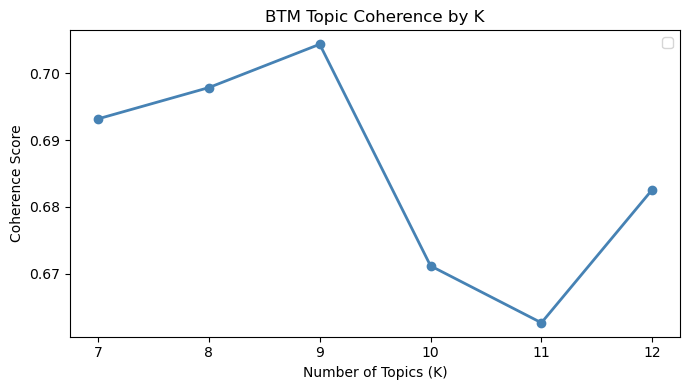

In [226]:
# ── Coherence plot ────────────────────────────────────────────────────────────
plt.figure(figsize=(7, 4))
plt.plot(list(coherence_scores.keys()), list(coherence_scores.values()),
         marker='o', linewidth=2, color='steelblue')
plt.xlabel('Number of Topics (K)')
plt.ylabel('Coherence Score')
plt.title('BTM Topic Coherence by K')
plt.xticks(K_values)
plt.legend()
plt.tight_layout()
plt.show()

In [227]:
for K in K_values:
    print(f'\n── K={K} ──────────────────────────────')
    topic_words_df = btm.get_top_topic_words(
        models[K].model_, words_num=12, topics_idx=None
    )
    for t in range(K):
        
        words = topic_words_df.iloc[:, t].tolist()
        print(f'  Topic {t:2d}: {" | ".join(words)}')


── K=7 ──────────────────────────────
  Topic  0: mazda | rijden | elektrisch | zakelijk | klasse | japans | vakmanschap | standaard | prijs | draai | rijder | stijlvol
  Topic  1: cht | mobiliteit | werkplek | koffie | zakelijk | kantoor | zorg | maken | aandacht | ontstaan | tikkie | prettig
  Topic  2: kans | proberen | lenzen | krant | pearle | zien | licht | data | bedrijf | brengen | firefly | landleven
  Topic  3: auto | mazda | zakelijk | ondernemer | kennis | betalen | krijgen | tijd | toyota | tikkie | kans | passen
  Topic  4: medewerker | verzuim | mening | ziek | frequent | gemiddeld | gaan | vaak | hiermee | waard | kwaliteitskoffie | plan
  Topic  5: magazine | branch | max | default | werkgever | defaullen | favoriet | hema | regelgeving | nummer | wet | tas
  Topic  6: bijtelling | beleggen | audi | zorgvastgoed | internationaal | gedoe | groeien | employer | fred | brand | verzek | rendement

── K=8 ──────────────────────────────
  Topic  0: mazda | zakelijk | rijden

In [270]:
# Set best model as K=9
best_K = 9
best_model = models[9]

# Define merge mapping: which K=9 topics merge into which final topic
# Based on top words inspection above
merge_map = {
    0: 0,  
    1: 0, 
    2: 1, 
    3: 2, 
    4: 3,  
    5: 4,  
    6: 3,  
    7: 5,  
    8: 6,  
}

# Final topic labels after merging
topic_labels_merged = {
    0: 'Workplace & Coffee',
    1: 'Business & HR',
    2: 'Health & Promotions',
    3: 'Automotive & Mobility',
    4: ' Wellbeing',
    5: 'Media & Lifestyle',
    6: 'Finance & Investment',
}

# Transform campaigns using K=9 model
campaign_topic_matrix_9 = best_model.transform(campaign_texts)

# Merge topic probabilities by summing
n_merged = len(topic_labels_merged)
campaign_topic_matrix_merged = np.zeros((len(campaign_texts), n_merged))

for original_topic, merged_topic in merge_map.items():
    campaign_topic_matrix_merged[:, merged_topic] += campaign_topic_matrix_9[:, original_topic]

# Normalise rows to sum to 1
row_sums = campaign_topic_matrix_merged.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
campaign_topic_matrix_merged /= row_sums

print('Sample merged campaign vectors:')
print(pd.DataFrame(campaign_topic_matrix_merged).head(5).round(3))
print('\nDominant topic counts after merging:')
dominant = campaign_topic_matrix_merged.argmax(axis=1)
print(pd.Series(dominant).map(topic_labels_merged).value_counts())

Sample merged campaign vectors:
     0    1      2      3      4      5    6
0  0.0  0.0  0.000  0.000  0.000  1.000  0.0
1  0.0  0.0  0.003  0.000  0.000  0.997  0.0
2  0.0  0.0  0.002  0.000  0.000  0.998  0.0
3  0.0  0.0  0.000  0.002  0.998  0.000  0.0
4  0.0  0.0  1.000  0.000  0.000  0.000  0.0

Dominant topic counts after merging:
Automotive & Mobility    53
Workplace & Coffee       29
Media & Lifestyle        25
Health & Promotions      24
Finance & Investment     20
Business & HR            18
 Wellbeing               10
Name: count, dtype: int64


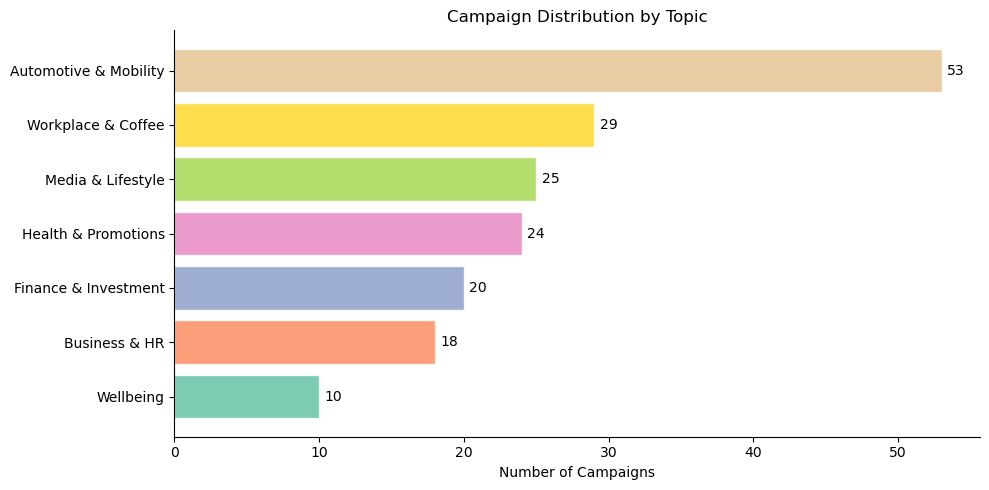

In [272]:
topic_dist = pd.Series({
    'Automotive & Mobility': 53,
    'Workplace & Coffee':       29,
    'Media & Lifestyle':     25,
    'Health & Promotions':   24,
    'Finance & Investment':  20,
    'Business & HR':         18,
    'Wellbeing':    10,
}).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.Set2.colors[:len(topic_dist)]

bars = ax.barh(topic_dist.index, topic_dist.values,
               color=colors, alpha=0.85, edgecolor='white')

for bar in bars:
    ax.annotate(f'{int(bar.get_width())}',
                xy=(bar.get_width(), bar.get_y() + bar.get_height()/2),
                xytext=(4, 0), textcoords='offset points',
                ha='left', va='center', fontsize=10)

ax.set_title('Campaign Distribution by Topic')
ax.set_xlabel('Number of Campaigns')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [274]:
# Assign merged dominant topic to each campaign
topic_cols_merged = [f'topic_{i}' for i in range(n_merged)]

campaign_docs['dominant_topic']       = dominant
campaign_docs['dominant_topic_label'] = campaign_docs['dominant_topic'].map(topic_labels_merged)

campaign_vectors = campaign_docs[['mailing_id', 'dominant_topic', 'dominant_topic_label']].copy()
for j, col in enumerate(topic_cols_merged):
    campaign_vectors[col] = campaign_topic_matrix_merged[:, j]

print(campaign_docs['dominant_topic_label'].value_counts())

dominant_topic_label
Automotive & Mobility    53
Workplace & Coffee       29
Media & Lifestyle        25
Health & Promotions      24
Finance & Investment     20
Business & HR            18
 Wellbeing               10
Name: count, dtype: int64


In [231]:
user_docs = (
    df_final[['user_id', 'interests']]
    .drop_duplicates(subset='user_id')
    .copy()
)

user_docs['text'] = user_docs['interests'].apply(
    lambda x: ' '.join(str(i) for i in x) if isinstance(x, list) else ''
)
user_docs = user_docs[user_docs['text'].str.strip() != ''].reset_index(drop=True)

print(f'User documents: {len(user_docs)}')
print(user_docs[['user_id', 'text']].head(3))

User documents: 19912
                    user_id                                               text
0  5cb9a38136dd1336b9c528d1  energie loterij kranten entertainment winactie...
1  5cb9a38336dd1336b9c537f3  auto loterij cx80 kranten mkb verzekering ente...
2  5cb9a38236dd1336b9c52f07  auto kranten auto inruilen windows bladen goed...


In [232]:
# Get BTM vocabulary from the inner model
btm_vocab = list(best_model.model_.vocabulary_)
btm_vocab_dict = {w: i for i, w in enumerate(btm_vocab)}

# Vectorise all user texts at once using CountVectorizer with BTM vocab
from sklearn.feature_extraction.text import CountVectorizer

user_texts = user_docs['text'].tolist()

vectorizer = CountVectorizer(vocabulary=btm_vocab_dict)
X_users = vectorizer.transform(user_texts)  # sparse, no loop

# Get phi matrix
phi = best_model.model_.matrix_topics_words_  # shape (K=9, vocab_size)

# Matrix multiplication: (n_users, vocab) @ (vocab, K) = (n_users, K)
user_topic_matrix_9 = X_users @ phi.T

# Normalise
row_sums = user_topic_matrix_9.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
user_topic_matrix_9 /= row_sums

print(f'User topic matrix shape: {user_topic_matrix_9.shape}')
print('Sample vectors:')
print(pd.DataFrame(user_topic_matrix_9).head(5).round(3))
print('\nDominant topic counts:')
print(pd.Series(user_topic_matrix_9.argmax(axis=1)).value_counts())

User topic matrix shape: (19912, 9)
Sample vectors:
       0      1      2      3      4      5      6      7      8
0  0.003  0.004  0.002  0.003  0.002  0.004  0.001  0.979  0.002
1  0.001  0.001  0.074  0.018  0.261  0.001  0.556  0.032  0.056
2  0.002  0.002  0.052  0.001  0.708  0.002  0.001  0.001  0.230
3  0.001  0.001  0.074  0.019  0.200  0.001  0.608  0.034  0.061
4  0.001  0.001  0.070  0.017  0.248  0.001  0.527  0.030  0.105

Dominant topic counts:
6    12368
7     4307
0     1678
8     1016
4      484
2       59
Name: count, dtype: int64


In [233]:
# How many users have at least one word matching BTM vocabulary?
non_zero = (user_topic_matrix_9.sum(axis=1) > 0).sum()
zero = (user_topic_matrix_9.sum(axis=1) == 0).sum()

print(f'Users with BTM vocab overlap: {non_zero} ({non_zero/len(user_docs):.1%})')
print(f'Users with NO vocab overlap:  {zero} ({zero/len(user_docs):.1%})')

Users with BTM vocab overlap: 18234 (91.6%)
Users with NO vocab overlap:  1678 (8.4%)


The vast majority of users have interest words that appear in the BTM campaign vocabulary. This means the topic vectors are meaningful for most users.
The 8.4% with no overlap likely have very niche interests that never appeared in any campaign subject line — they can be excluded from the analysis or assigned the global average topic distribution.

In [276]:
# Apply merge map to user topic matrix
user_topic_matrix_merged = np.zeros((len(user_docs), n_merged))
for original_topic, merged_topic in merge_map.items():
    user_topic_matrix_merged[:, merged_topic] += user_topic_matrix_9[:, original_topic]

# Normalise
row_sums = user_topic_matrix_merged.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
user_topic_matrix_merged /= row_sums

# Assign dominant topic
user_docs['dominant_topic']       = user_topic_matrix_merged.argmax(axis=1)
user_docs['dominant_topic_label'] = user_docs['dominant_topic'].map(topic_labels_merged)

# Flag users with no vocab overlap
user_docs['has_vocab_overlap'] = user_topic_matrix_9.sum(axis=1) > 0

# Build user vectors dataframe
user_vectors = user_docs[['user_id']].copy()
for j, col in enumerate(topic_cols_merged):
    user_vectors[col] = user_topic_matrix_merged[:, j]

print(f'User vectors shape: {user_vectors.shape}')
print('\nUser interest profile distribution:')
print(user_docs[user_docs['has_vocab_overlap']]['dominant_topic_label'].value_counts())

User vectors shape: (19912, 8)

User interest profile distribution:
dominant_topic_label
Automotive & Mobility    12852
Media & Lifestyle         4307
Finance & Investment      1016
Business & HR               59
Name: count, dtype: int64


Only 4 out of 7 topics have user interest profiles — and Automotive & Mobility dominates massively (70% of users). This makes sense given the dataset is heavily automotive-focused (Mazda, Audi, etc.).
Business & HR (59 users) and the missing topics (B2B & Workplace, Health & Promotions, Employee Wellbeing) have no or almost no user interest representation — because those topics are B2B/corporate campaigns that don't map to individual consumer interests.

In [237]:
# Only use users with vocab overlap
user_docs_valid = user_docs[user_docs['has_vocab_overlap']].copy()
user_vectors_valid = user_vectors[user_docs['has_vocab_overlap'].values].copy()

print(f'Users for analysis: {len(user_docs_valid)}')

# Cosine similarity for observed pairs
user_id_to_idx = {uid: i for i, uid in enumerate(user_vectors_valid['user_id'].values)}
camp_id_to_idx = {mid: j for j, mid in enumerate(campaign_vectors['mailing_id'].values)}

pairs = (
    df_final[['user_id', 'mailing_id', 'open', 'click']]
    .dropna(subset=['open'])
    .merge(user_vectors_valid[['user_id']], on='user_id', how='inner')
    .merge(campaign_vectors[['mailing_id']], on='mailing_id', how='inner')
    .drop_duplicates(subset=['user_id', 'mailing_id'])
    .copy()
)

pairs['user_idx'] = pairs['user_id'].map(user_id_to_idx)
pairs['camp_idx'] = pairs['mailing_id'].map(camp_id_to_idx)
pairs = pairs.dropna(subset=['user_idx', 'camp_idx'])
pairs[['user_idx', 'camp_idx']] = pairs[['user_idx', 'camp_idx']].astype(int)

U = user_vectors_valid[topic_cols_merged].values
C = campaign_vectors[topic_cols_merged].values
sim_matrix = cosine_similarity(U, C)

pairs['cosine_similarity'] = sim_matrix[
    pairs['user_idx'].values,
    pairs['camp_idx'].values
]

print(f'Pairs: {len(pairs)}')

Users for analysis: 18234
Pairs: 813613


In [238]:
# Objective 1: Campaign topic engagement
df_analysis = df_final.merge(
    campaign_docs[['mailing_id', 'dominant_topic_label']],
    on='mailing_id', how='left'
)

topic_engagement = (
    df_analysis.groupby('dominant_topic_label')
    .agg(
        n_campaigns=('mailing_id', 'nunique'),
        n_exposures=('user_id', 'count'),
        open_rate=('open', 'mean'),
        click_rate=('click', 'mean')
    )
    .sort_values('open_rate', ascending=False)
    .reset_index()
)
print(topic_engagement.round(3).to_string(index=False))

 dominant_topic_label  n_campaigns  n_exposures  open_rate  click_rate
Automotive & Mobility           53       201968      0.585       0.002
      B2B & Workplace           29       144404      0.554       0.001
    Media & Lifestyle           25       259244      0.527       0.000
        Business & HR           18        28027      0.524       0.001
  Health & Promotions           24       156320      0.521       0.001
   Employee Wellbeing           10        36105      0.521       0.000
 Finance & Investment           20        85327      0.479       0.001


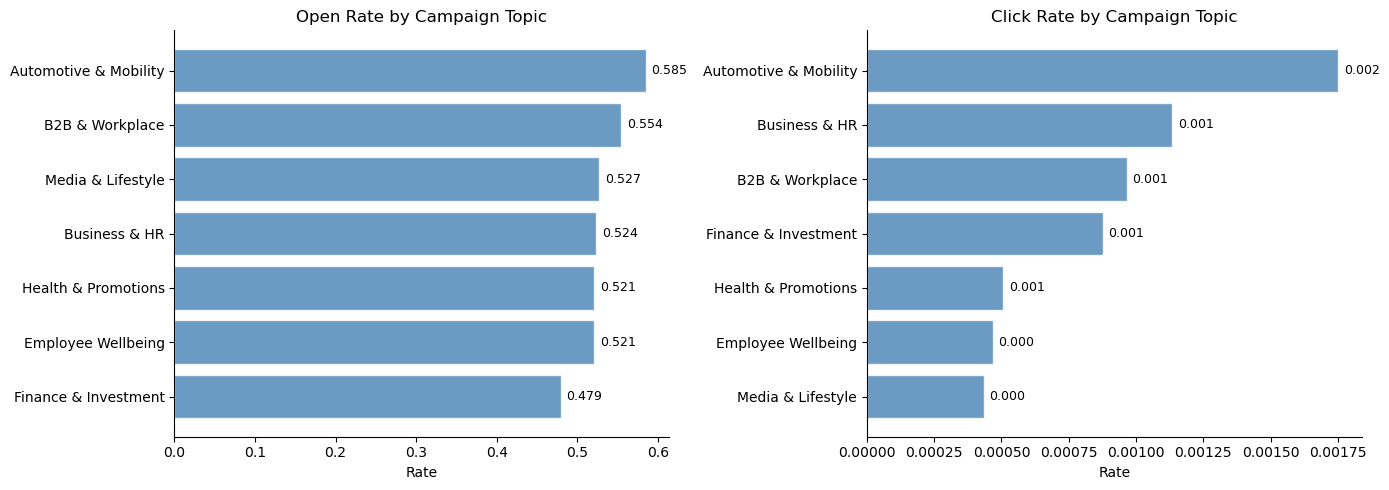

In [239]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in zip(axes,
    ['open_rate', 'click_rate'],
    ['Open Rate by Campaign Topic', 'Click Rate by Campaign Topic']):
    sorted_df = topic_engagement.sort_values(col)
    bars = ax.barh(sorted_df['dominant_topic_label'], sorted_df[col],
                   color='steelblue', alpha=0.8, edgecolor='white')
    for bar in bars:
        ax.annotate(f'{bar.get_width():.3f}',
                    xy=(bar.get_width(), bar.get_y() + bar.get_height()/2),
                    xytext=(4, 0), textcoords='offset points',
                    ha='left', va='center', fontsize=9)
    ax.set_title(title)
    ax.set_xlabel('Rate')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [240]:
# For a given campaign, rank ALL users by cosine similarity
# This uses full topic vectors — no information loss

def recommend_users_for_campaign(mailing_id_val, top_pct=0.3):
    idx = camp_id_to_idx.get(mailing_id_val)
    if idx is None:
        print(f'Campaign {mailing_id_val} not found.')
        return None
    
    scores = sim_matrix[:, idx]
    top_n = int(len(user_vectors_valid) * top_pct)
    top_idx = np.argsort(scores)[::-1][:top_n]
    
    result = pd.DataFrame({
        'user_id':           user_vectors_valid['user_id'].values[top_idx],
        'cosine_similarity': scores[top_idx]
    }).merge(
        user_docs_valid[['user_id', 'interests']],
        on='user_id', how='left'
    )
    return result

# Show recommended users with their full interests
sample_campaign = campaign_vectors['mailing_id'].values[0]
campaign_topic  = campaign_vectors['dominant_topic_label'].values[0]
subject_line    = campaign_docs[campaign_docs['mailing_id'] == sample_campaign]['subject_line'].values[0]

print(f'Campaign: {sample_campaign}')
print(f'Topic: {campaign_topic}')
print(f'Subject: {subject_line}')
print(f'\nTop 10 most aligned users:')
targets = recommend_users_for_campaign(sample_campaign, top_pct=0.3)
print(targets[['user_id', 'cosine_similarity', 'interests']].head(10).to_string(index=False))

Campaign: 668
Topic: Media & Lifestyle
Subject: Lezen, puzzelen, genieten: 4 edities cadeau

Top 10 most aligned users:
                 user_id  cosine_similarity                                                                                                    interests
5c6bed715798a7942837dd89            0.99995                                              [kranten, winactie, bladen, kortingen, energie, cadeau, acties]
5c6bec365798a79428341612            0.99995                                                                         [kranten, bladen, onderzoek, cadeau]
5c6bec355798a79428340bca            0.99995                                                                         [kranten, bladen, onderzoek, cadeau]
5c6bec355798a79428340c20            0.99995                                   [kranten, winactie, bladen, kortingen, onderzoek, energie, cadeau, acties]
5c6bec385798a79428342742            0.99995                                                                        

In [241]:
def score_new_campaign(subject_line, top_n=10, top_pct=None):
    # 1. Preprocess exactly as done for the training corpus
    clean_text = preprocess(subject_line)
    if not clean_text.strip():
        raise ValueError(
            "Subject line produced no usable tokens after preprocessing "
            "(only stopwords / non-alphabetic content). Cannot score this campaign."
        )

    # 2. Vectorise against the EXISTING fitted vocabulary (no retraining)
    new_vec = vectorizer.transform([clean_text])  # uses btm_vocab_dict fixed at fit time

    if new_vec.sum() == 0:
        raise ValueError(
            "None of the words in this subject line appear in the BTM training vocabulary. "
            "This campaign cannot be placed in the existing topic space without retraining."
        )

    # 3. Project onto the 9-topic space via the learned phi matrix, then merge to 7 topics
    new_topic_9 = new_vec @ phi.T  # shape (1, 9)
    new_topic_9 = np.asarray(new_topic_9)
    row_sum = new_topic_9.sum(axis=1, keepdims=True)
    row_sum[row_sum == 0] = 1
    new_topic_9 = new_topic_9 / row_sum

    new_topic_merged = np.zeros((1, n_merged))
    for original_topic, merged_topic in merge_map.items():
        new_topic_merged[:, merged_topic] += new_topic_9[:, original_topic]
    row_sum = new_topic_merged.sum(axis=1, keepdims=True)
    row_sum[row_sum == 0] = 1
    new_topic_merged = new_topic_merged / row_sum

    dominant_idx = int(new_topic_merged.argmax(axis=1)[0])
    dominant_label = topic_labels_merged[dominant_idx]

    # 4. Cosine similarity against every existing user topic vector
    U = user_vectors_valid[topic_cols_merged].values
    sims = cosine_similarity(U, new_topic_merged).flatten()

    if top_pct is not None:
        n_select = max(1, int(len(user_vectors_valid) * top_pct))
    else:
        n_select = min(top_n, len(user_vectors_valid))

    top_idx = np.argsort(sims)[::-1][:n_select]

    targets = pd.DataFrame({
        'user_id': user_vectors_valid['user_id'].values[top_idx],
        'cosine_similarity': sims[top_idx]
    }).merge(
        user_docs_valid[['user_id', 'interests']],
        on='user_id', how='left'
    )

    return {
        'subject_line': subject_line,
        'clean_text': clean_text,
        'topic_vector': new_topic_merged.flatten(),
        'dominant_topic': dominant_idx,
        'dominant_topic_label': dominant_label,
        'targets': targets
    }


# ── Demo: score a new, never-seen subject line ──────────────────────────────
new_subject = "Kies en lees: 4 weken de krant voor 1 euro p/w"

result = score_new_campaign(new_subject, top_n=10)

print(f"New subject line: {result['subject_line']}")
print(f"Cleaned text:     {result['clean_text']}")
print(f"Topic vector:     {np.round(result['topic_vector'], 3)}")
print(f"Dominant topic:   {result['dominant_topic']} ({result['dominant_topic_label']})")
print(f"\nTop {len(result['targets'])} recommended users:")
print(result['targets'].to_string(index=False))

New subject line: Kies en lees: 4 weken de krant voor 1 euro p/w
Cleaned text:     lees krant
Topic vector:     [0.006 0.002 0.527 0.002 0.003 0.458 0.002]
Dominant topic:   2 (Health & Promotions)

Top 10 recommended users:
                 user_id  cosine_similarity                                                                                                    interests
5c6bed715798a7942837dd89           0.657778                                              [kranten, winactie, bladen, kortingen, energie, cadeau, acties]
5c6bec365798a79428341612           0.657778                                                                         [kranten, bladen, onderzoek, cadeau]
5c6bec355798a79428340bca           0.657778                                                                         [kranten, bladen, onderzoek, cadeau]
5c6bec355798a79428340c20           0.657778                                   [kranten, winactie, bladen, kortingen, onderzoek, energie, cadeau, acties]
5c6bec3857

# Decision Trees

In [243]:
# sort mailing id by timeline (proxy)
df_history = df_final_time.sort_values(['user_id', 'mailing_id']).copy()

# past cummulative opens (how many opens before this email?)
df_history['past_opens'] = (df_history.groupby('user_id')['open'].cumsum() - df_history['open'])

# past cummulative clicks (how many clicks before this email?)
df_history['past_clicks'] = (df_history.groupby('user_id')['click'].cumsum() - df_history['click'])

# cummulative email received before current email
df_history['emails_before'] = (df_history.groupby('user_id').cumcount())

# past open rate (average open rate for all email received before current one)
df_history['past_open_rate'] = (df_history['past_opens']/df_history['emails_before'])

# past click rate (average click rate for all email received before current one)
df_history['past_click_rate'] = (df_history['past_clicks']/df_history['emails_before'])

In [244]:
# ═══════════════════════════════════════════════════════════════════════════════
# DECISION TREE — FULL PIPELINE
# Using corrected past open/click rates from df_history (cumulative, excluding
# current email to avoid data leakage)
# ═══════════════════════════════════════════════════════════════════════════════

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, make_scorer)
from sklearn.preprocessing import LabelEncoder
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

le = LabelEncoder()

In [245]:
# ── Feature definitions ───────────────────────────────────────────────────────
# BTM features: user topic vectors (from interest labels projected via phi matrix)
#               campaign topic vectors (from BTM transform)
#               cosine similarity between user and campaign topic vectors
# Behavioural features: corrected past open/click rate (cumulative, excl. current)
#                       emails_before (number of emails received before current)
#                       gender (encoded), age
# NOTE: n_interests excluded as it does not directly relate to content engagement

topic_cols_user     = [f'user_topic_{i}' for i in range(n_merged)]
topic_cols_campaign = [f'campaign_topic_{i}' for i in range(n_merged)]
btm_cols            = topic_cols_user + topic_cols_campaign + ['cosine_similarity']
behavioural_cols    = ['past_open_rate', 'past_click_rate',
                       'emails_before', 'gender_enc', 'age']
all_feature_cols    = btm_cols + behavioural_cols

print('BTM features:',        btm_cols)
print('Behavioural features:', behavioural_cols)

BTM features: ['user_topic_0', 'user_topic_1', 'user_topic_2', 'user_topic_3', 'user_topic_4', 'user_topic_5', 'user_topic_6', 'campaign_topic_0', 'campaign_topic_1', 'campaign_topic_2', 'campaign_topic_3', 'campaign_topic_4', 'campaign_topic_5', 'campaign_topic_6', 'cosine_similarity']
Behavioural features: ['past_open_rate', 'past_click_rate', 'emails_before', 'gender_enc', 'age']


In [246]:
# ── Rename topic vectors to avoid column name collision ───────────────────────
# user_vectors_valid: topic vectors derived from user interest labels
#                     projected onto BTM topic space via phi matrix
# campaign_vectors:   topic vectors derived from BTM transform of subject lines

user_vec_dt = user_vectors_valid.copy()
user_vec_dt.columns = ['user_id'] + topic_cols_user

campaign_vec_dt = campaign_vectors[['mailing_id'] + topic_cols_merged].copy()
campaign_vec_dt.columns = ['mailing_id'] + topic_cols_campaign

In [247]:
# ── Assemble feature matrix ───────────────────────────────────────────────────
# Source: df_history contains corrected cumulative past open/click rates
# past_open_rate  = sum of opens before current email / emails_before
# past_click_rate = sum of clicks before current email / emails_before
# emails_before   = cumulative count of emails received before current
# First email per user has past_open_rate = NaN → filled with 0

df_model = (
    df_history[['user_id', 'mailing_id', 'open', 'click',
                'gender', 'age',
                'past_open_rate', 'past_click_rate', 'emails_before']]
    .dropna(subset=['open'])
    .merge(pairs[['user_id', 'mailing_id', 'cosine_similarity']],
           on=['user_id', 'mailing_id'], how='left')
    .merge(user_vec_dt,     on='user_id',    how='left')
    .merge(campaign_vec_dt, on='mailing_id', how='left')
    .merge(campaign_docs[['mailing_id', 'dominant_topic_label']],
           on='mailing_id', how='left')
)

df_model['gender_enc']      = le.fit_transform(df_model['gender'].fillna('unknown'))
df_model['past_open_rate']  = df_model['past_open_rate'].fillna(0)
df_model['past_click_rate'] = df_model['past_click_rate'].fillna(0)

print(f'Feature matrix shape: {df_model.shape}')
print(f'Open rate: {df_model["open"].mean():.4f}')
print(f'Click rate: {df_model["click"].mean():.4f}')

Feature matrix shape: (1057544, 26)
Open rate: 0.5362
Click rate: 0.0011


In [248]:
# ── Build tuning dataset ──────────────────────────────────────────────────────
df_tune = df_model[all_feature_cols + ['open']].dropna()
X_tune  = df_tune[all_feature_cols]
y_tune  = df_tune['open'].astype(int)

print(f'Tuning dataset shape: {X_tune.shape}')
print(f'Open rate: {y_tune.mean():.4f}')

Tuning dataset shape: (208597, 20)
Open rate: 0.5223


In [249]:
# ── Validation curve for max_depth using ROC-AUC ──────────────────────────────
from sklearn.model_selection import validation_curve, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
import numpy as np
import matplotlib.pyplot as plt

param_grid = {'max_depth': [3, 4, 5, 6, 7, 8, 10, 12, 15]}

train_scores, val_scores = validation_curve(
    DecisionTreeClassifier(
        min_samples_leaf=30,
        class_weight='balanced',
        random_state=42
    ),
    X_tune, y_tune,
    param_name='max_depth',
    param_range=param_grid['max_depth'],
    cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

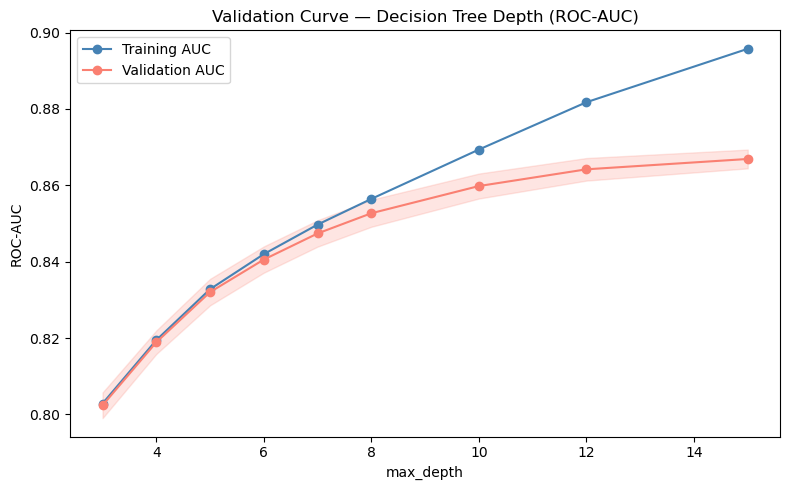

In [250]:
# ── Plot validation curve ─────────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.plot(param_grid['max_depth'], train_mean,
         marker='o', label='Training AUC', color='steelblue')
plt.plot(param_grid['max_depth'], val_mean,
         marker='o', label='Validation AUC', color='salmon')
plt.fill_between(param_grid['max_depth'],
                 val_mean - val_std,
                 val_mean + val_std,
                 alpha=0.2, color='salmon')
plt.xlabel('max_depth')
plt.ylabel('ROC-AUC')
plt.title('Validation Curve — Decision Tree Depth (ROC-AUC)')
plt.legend()
plt.tight_layout()
plt.show()

## Single Decision Tree

In [254]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd

In [256]:
# ══════════════════════════════════════════════════════════════════════════════
# PART 1 — SINGLE DECISION TREE ON FULL DATASET
# 5-fold stratified cross-validation on all users
# Stratified to maintain class balance (open/no-open ratio) across folds
# ══════════════════════════════════════════════════════════════════════════════
df_full = df_model[all_feature_cols + ['open']].dropna()
X_full  = df_full[all_feature_cols]
y_full  = df_full['open'].astype(int)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

dt_full = DecisionTreeClassifier(
    max_depth=8,
    min_samples_leaf=50,
    class_weight='balanced',  # handles class imbalance
    random_state=42
)

auc_scores_full = cross_val_score(dt_full, X_full, y_full,
                                   cv=cv, scoring='roc_auc')

print(f'Decision Tree — Full Dataset (10-fold CV)')
print(f'  AUC per fold: {auc_scores_full.round(4)}')
print(f'  Mean AUC: {auc_scores_full.mean():.4f} ± {auc_scores_full.std():.4f}')

Decision Tree — Full Dataset (10-fold CV)
  AUC per fold: [0.8498 0.8541 0.8505 0.846  0.8513 0.8533 0.8536 0.8604 0.8543 0.8523]
  Mean AUC: 0.8526 ± 0.0035


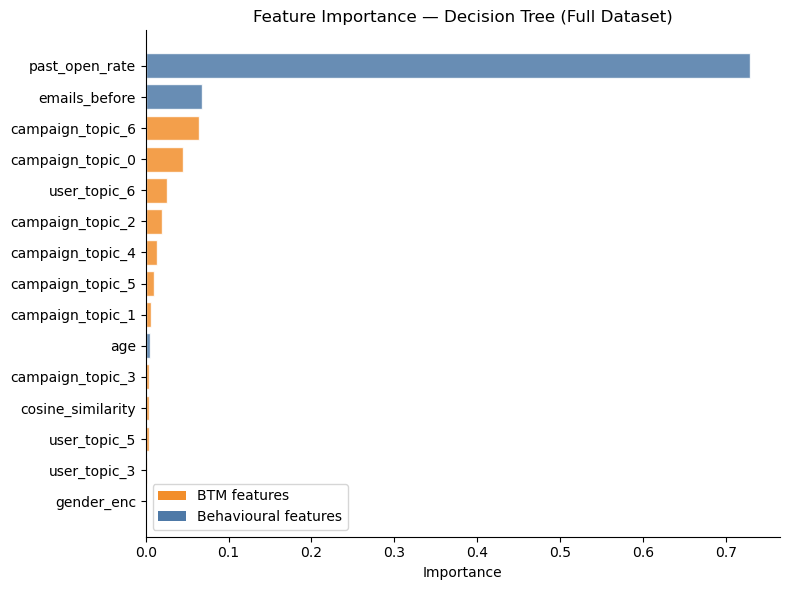

In [258]:
# ── Feature importance on full dataset ───────────────────────────────────────
# Fit once on full data to get feature importance
dt_full.fit(X_full, y_full)

imp_df = pd.DataFrame({
    'feature':    all_feature_cols,
    'importance': dt_full.feature_importances_
}).sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#f28e2b' if f in btm_cols else '#4e79a7'
          for f in imp_df['feature'][::-1]]
ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1],
        color=colors, alpha=0.85, edgecolor='white')
legend_elements = [
    Patch(facecolor='#f28e2b', label='BTM features'),
    Patch(facecolor='#4e79a7', label='Behavioural features')
]
ax.legend(handles=legend_elements)
ax.set_title('Feature Importance — Decision Tree (Full Dataset)')
ax.set_xlabel('Importance')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [259]:
print('Feature importance — Decision Tree (Full Dataset):')
print(imp_df.to_string(index=False))

print(f'\nBTM importance (sum):         {imp_df[imp_df["feature"].isin(btm_cols)]["importance"].sum():.4f}')
print(f'Behavioural importance (sum): {imp_df[imp_df["feature"].isin(behavioural_cols)]["importance"].sum():.4f}')

imp_df_top15 = imp_df.head(15)

Feature importance — Decision Tree (Full Dataset):
          feature  importance
   past_open_rate    0.728995
    emails_before    0.068047
 campaign_topic_6    0.064231
 campaign_topic_0    0.045253
     user_topic_6    0.025230
 campaign_topic_2    0.019988
 campaign_topic_4    0.013491
 campaign_topic_5    0.010489
 campaign_topic_1    0.005788
              age    0.004781
 campaign_topic_3    0.003891
cosine_similarity    0.003627
     user_topic_5    0.003378
     user_topic_3    0.001859
       gender_enc    0.000515

BTM importance (sum):         0.1972
Behavioural importance (sum): 0.8023


In [260]:
# ══════════════════════════════════════════════════════════════════════════════
# DECISION TREE — BEHAVIOURAL FEATURES ONLY (no BTM)
# This serves as the baseline to isolate BTM's contribution:
# comparing BTM+Behavioural vs Behavioural only shows exactly
# how much BTM topic features add beyond pure behavioural signals
# ══════════════════════════════════════════════════════════════════════════════

df_beh = df_model[behavioural_cols + ['open']].dropna()
X_beh  = df_beh[behavioural_cols]
y_beh  = df_beh['open'].astype(int)

dt_beh = DecisionTreeClassifier(
    max_depth=8,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=42
)

auc_scores_full = cross_val_score(dt_beh, X_beh, y_beh,
                                   cv=cv, scoring='roc_auc')

print(f'Decision Tree — Behavioral only (10-fold CV)')
print(f'  AUC per fold: {auc_scores_full.round(4)}')
print(f'  Mean AUC: {auc_scores_full.mean():.4f} ± {auc_scores_full.std():.4f}')

Decision Tree — Behavioral only (10-fold CV)
  AUC per fold: [0.8218 0.8214 0.8224 0.8271 0.8221 0.822  0.8221 0.8243 0.8225 0.8254]
  Mean AUC: 0.8231 ± 0.0018


## Segmented Decision Trees

In [262]:
# ══════════════════════════════════════════════════════════════════════════════
# PART 2 — SEGMENTED DECISION TREES
# Build separate trees for 4 user groups:
# - High Open / Low Open: split by median past_open_rate
# - High Click / Low Click: split by median past_click_rate
#   (even though clicks are sparse, class_weight='balanced' handles imbalance)
# Each group uses 5-fold stratified CV
# Purpose: show whether BTM topic features matter more within specific segments
# ══════════════════════════════════════════════════════════════════════════════

# Compute segment thresholds from full dataset
open_thresh  = df_model['past_open_rate'].median()

print(f'Open threshold (median):  {open_thresh:.4f}')

# Assign segments
df_model['open_segment']  = df_model['past_open_rate'].apply(
    lambda x: 'High Open' if x >= open_thresh else 'Low Open'
)

print('\nOpen segment distribution:')
print(df_model['open_segment'].value_counts())

Open threshold (median):  0.5870

Open segment distribution:
open_segment
High Open    528929
Low Open     528615
Name: count, dtype: int64


In [263]:
# ── Click segment: only users who have clicked at least once ──────────────────
# Since clicks are extremely rare (~0.1%), building a click model on all users
# is not meaningful. Instead we focus only on users who have clicked at least
# once, then split that group into High Click / Low Click by median click rate.
# This gives a more meaningful analysis of what drives click behaviour
# among users who are already known to click.

# Filter to users who have clicked at least once
users_who_click = (
    df_model[df_model['click'] == 1]['user_id']
    .unique()
)

df_clickers = df_model[df_model['user_id'].isin(users_who_click)].copy()

print(f'Total users: {df_model["user_id"].nunique()}')
print(f'Users who clicked at least once: {len(users_who_click)} '
      f'({len(users_who_click)/df_model["user_id"].nunique():.1%})')
print(f'Rows for click analysis: {len(df_clickers)}')
print(f'Click rate within this group: {df_clickers["click"].mean():.4f}')

Total users: 17963
Users who clicked at least once: 182 (1.0%)
Rows for click analysis: 11560
Click rate within this group: 0.0935


In [264]:
# ── Split clickers into High Click / Low Click by median click rate ───────────
click_thresh_clickers = df_clickers['past_click_rate'].median()
print(f'Click threshold (median among clickers): {click_thresh_clickers:.4f}')

df_clickers['click_segment'] = df_clickers['past_click_rate'].apply(
    lambda x: 'High Click' if x >= click_thresh_clickers else 'Low Click'
)

print(df_clickers['click_segment'].value_counts())
print('\nClick rate per segment:')
print(df_clickers.groupby('click_segment')['click'].mean())

Click threshold (median among clickers): 0.0577
click_segment
High Click    5819
Low Click     5741
Name: count, dtype: int64

Click rate per segment:
click_segment
High Click    0.123561
Low Click     0.063055
Name: click, dtype: float64


In [285]:
# ══════════════════════════════════════════════════════════════════════════════
# SEGMENTED DECISION TREES — BTM + BEHAVIOURAL ONLY
# For each segment, build one tree (BTM + Behavioural) and report:
# - Mean AUC-ROC across 10-fold CV
# - BTM vs Behavioural feature importance
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
import pandas as pd

segment_results = {}

# ── Open segments (target = open) ────────────────────────────────────────────
for segment in ['High Open', 'Low Open']:
    seg_df = df_model[df_model['open_segment'] == segment].copy()
    seg_df = seg_df[all_feature_cols + ['open']].dropna()
    target = 'open'

    print(f'\n══ {segment} (n={len(seg_df)}, open rate={seg_df[target].mean():.4f}) ══')

    if len(seg_df) < 200 or seg_df[target].nunique() < 2:
        print('   Skipping')
        continue

    X_seg  = seg_df[all_feature_cols]
    y_seg  = seg_df[target].astype(int)
    cv_seg = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    dt_all_seg = DecisionTreeClassifier(
        max_depth=8, min_samples_leaf=30,
        class_weight='balanced', random_state=42
    )

    auc_scores = cross_val_score(dt_all_seg, X_seg, y_seg,
                                  cv=cv_seg, scoring='roc_auc')

    print(f'  Mean AUC: {auc_scores.mean():.4f} ± {auc_scores.std():.4f}')

    # Feature importance (fit once on full segment data)
    dt_all_seg.fit(X_seg, y_seg)
    imp_seg = pd.DataFrame({
        'feature':    all_feature_cols,
        'importance': dt_all_seg.feature_importances_
    }).sort_values('importance', ascending=False)
    btm_imp = imp_seg[imp_seg['feature'].isin(btm_cols)]['importance'].sum()
    beh_imp = imp_seg[imp_seg['feature'].isin(behavioural_cols)]['importance'].sum()
    print(f'  BTM importance: {btm_imp:.4f} | Behavioural importance: {beh_imp:.4f}')

    segment_results[segment] = {
        'auc_mean': auc_scores.mean(),
        'auc_std':  auc_scores.std(),
        'btm_importance': btm_imp,
        'behavioural_importance': beh_imp
    }

# ── Click segments (target = click, clickers only) ───────────────────────────
for segment in ['High Click', 'Low Click']:
    seg_df = df_clickers[df_clickers['click_segment'] == segment].copy()
    seg_df = seg_df[all_feature_cols + ['click']].dropna()
    target = 'click'

    print(f'\n══ {segment} — clickers only (n={len(seg_df)}, '
          f'click rate={seg_df[target].mean():.4f}) ══')

    if len(seg_df) < 200 or seg_df[target].nunique() < 2:
        print('   Skipping')
        continue

    X_seg  = seg_df[all_feature_cols]
    y_seg  = seg_df[target].astype(int)
    cv_seg = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    dt_all_seg = DecisionTreeClassifier(
        max_depth=8, min_samples_leaf=30,
        class_weight='balanced', random_state=42
    )

    auc_scores = cross_val_score(dt_all_seg, X_seg, y_seg,
                                  cv=cv_seg, scoring='roc_auc')

    print(f'  Mean AUC: {auc_scores.mean():.4f} ± {auc_scores.std():.4f}')

    # Feature importance (fit once on full segment data)
    dt_all_seg.fit(X_seg, y_seg)
    imp_seg = pd.DataFrame({
        'feature':    all_feature_cols,
        'importance': dt_all_seg.feature_importances_
    }).sort_values('importance', ascending=False)
    btm_imp = imp_seg[imp_seg['feature'].isin(btm_cols)]['importance'].sum()
    beh_imp = imp_seg[imp_seg['feature'].isin(behavioural_cols)]['importance'].sum()
    print(f'  BTM importance: {btm_imp:.4f} | Behavioural importance: {beh_imp:.4f}')

    segment_results[segment] = {
        'auc_mean': auc_scores.mean(),
        'auc_std':  auc_scores.std(),
        'btm_importance': btm_imp,
        'behavioural_importance': beh_imp
    }


══ High Open (n=98670, open rate=0.7655) ══
  Mean AUC: 0.8001 ± 0.0030
  BTM importance: 0.4286 | Behavioural importance: 0.5714

══ Low Open (n=109927, open rate=0.3040) ══
  Mean AUC: 0.7601 ± 0.0035
  BTM importance: 0.3528 | Behavioural importance: 0.6472

══ High Click — clickers only (n=1285, click rate=0.0755) ══
  Mean AUC: 0.8601 ± 0.0508
  BTM importance: 0.5649 | Behavioural importance: 0.4351

══ Low Click — clickers only (n=1456, click rate=0.0495) ══
  Mean AUC: 0.8630 ± 0.0416
  BTM importance: 0.7335 | Behavioural importance: 0.2665


## Evaluation & Comparision (AUC)

In [278]:
# ── ROC-AUC scoring setup ──────────────────────────────────────────────────────
# AUC-ROC measures how well the model ranks positive cases (opens/clicks)
# above negative cases across all classification thresholds, making it
# threshold-independent unlike precision/recall/F1/accuracy

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
import numpy as np
import pandas as pd

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [279]:
# ── Single decision tree — Full dataset (BTM + Behavioural) ──────────────────
df_full = df_model[all_feature_cols + ['open']].dropna()
X_full  = df_full[all_feature_cols]
y_full  = df_full['open'].astype(int)

dt_full = DecisionTreeClassifier(
    max_depth=8,
    min_samples_leaf=30,
    class_weight='balanced',
    random_state=42
)

auc_scores_full = cross_val_score(dt_full, X_full, y_full,
                                   cv=cv, scoring='roc_auc')

print(f'Decision Tree — BTM + Behavioural (10-fold CV)')
print(f'  AUC per fold: {auc_scores_full.round(4)}')
print(f'  Mean AUC: {auc_scores_full.mean():.4f} ± {auc_scores_full.std():.4f}')

Decision Tree — BTM + Behavioural (10-fold CV)
  AUC per fold: [0.8496 0.8542 0.8505 0.8463 0.8514 0.8534 0.8538 0.8606 0.8542 0.8529]
  Mean AUC: 0.8527 ± 0.0035


In [280]:
# ── Single decision tree — Behavioural Only ───────────────────────────────────
df_beh = df_model[behavioural_cols + ['open']].dropna()
X_beh  = df_beh[behavioural_cols]
y_beh  = df_beh['open'].astype(int)

dt_beh = DecisionTreeClassifier(
    max_depth=8,
    min_samples_leaf=30,
    class_weight='balanced',
    random_state=42
)

auc_scores_beh = cross_val_score(dt_beh, X_beh, y_beh,
                                  cv=cv, scoring='roc_auc')

print(f'\nDecision Tree — Behavioural Only (10-fold CV)')
print(f'  AUC per fold: {auc_scores_beh.round(4)}')
print(f'  Mean AUC: {auc_scores_beh.mean():.4f} ± {auc_scores_beh.std():.4f}')


Decision Tree — Behavioural Only (10-fold CV)
  AUC per fold: [0.8222 0.8213 0.8224 0.8275 0.822  0.8221 0.8225 0.8244 0.8224 0.8253]
  Mean AUC: 0.8232 ± 0.0018


### Baselines

In [309]:
# ── Build demographic segment ─────────────────────────────────────────────────

def age_group(age):
    if pd.isna(age):   return 'Unknown'
    elif age < 25:     return '18-24'
    elif age < 35:     return '25-34'
    elif age < 45:     return '35-44'
    elif age < 55:     return '45-54'
    elif age < 65:     return '55-64'
    else:              return '65+'

df_model['age_group']    = df_model['age'].apply(age_group)
df_model['demo_segment'] = (
    df_model['gender'].fillna('unknown') + '_' + df_model['age_group']
)

# ── Demographic segmentation prediction function ──────────────────────────────
def demo_pred(train_df, test_df):
    rate = train_df.groupby('demo_segment')['open'].mean()
    global_rate = train_df['open'].mean()
    return test_df['demo_segment'].map(rate).fillna(global_rate)

In [311]:
# ── 10-fold CV AUC for demographic segmentation ───────────────────────────────
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import numpy as np

def cv_auc_segmentation(df, pred_fn, target='open', n_splits=10):
    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    auc_scores = []
    y_all   = df[target].fillna(0).astype(int).values
    indices = np.arange(len(df))

    for train_idx, test_idx in kf.split(indices, y_all):
        train_df = df.iloc[train_idx]
        test_df  = df.iloc[test_idx]

        preds = pred_fn(train_df, test_df)
        y_te  = test_df[target].fillna(0).astype(int)

        valid = y_te.notna() & preds.notna()
        if valid.sum() == 0:
            continue

        y_te_valid  = y_te[valid]
        preds_valid = preds[valid]

        if y_te_valid.nunique() > 1:
            auc_scores.append(roc_auc_score(y_te_valid, preds_valid))

    return np.array(auc_scores)


df_cv_demo = df_model[['open', 'demo_segment']].dropna(subset=['open'])

auc_demo = cv_auc_segmentation(df_cv_demo, demo_pred)

print(f'\nDemographic Segmentation (10-fold CV)')
print(f'  AUC per fold: {auc_demo.round(4)}')
print(f'  Mean AUC: {auc_demo.mean():.4f} ± {auc_demo.std():.4f}')


Demographic Segmentation (10-fold CV)
  AUC per fold: [0.5328 0.5367 0.5362 0.533  0.5362 0.5306 0.534  0.5349 0.5343 0.5358]
  Mean AUC: 0.5344 ± 0.0018


In [316]:
# ── Build campaign and user dominant topic columns ────────────────────────────
# Campaign's dominant topic (from BTM transform of subject line)
campaign_topic_df = campaign_docs[['mailing_id', 'dominant_topic_label']].rename(
    columns={'dominant_topic_label': 'campaign_topic_label'}
)

# User's dominant interest topic (from projecting interests onto BTM topic space)
user_topic_df = user_docs[['user_id', 'dominant_topic_label']].rename(
    columns={'dominant_topic_label': 'user_topic_label'}
)

df_topic_seg = (
    df_model[['user_id', 'mailing_id', 'open']]
    .merge(user_topic_df, on='user_id', how='left')
    .merge(campaign_topic_df, on='mailing_id', how='left')
)

print(df_topic_seg.columns.tolist())
print(df_topic_seg[['user_id', 'mailing_id', 'user_topic_label',
                     'campaign_topic_label', 'open']].head())

['user_id', 'mailing_id', 'open', 'user_topic_label', 'campaign_topic_label']
                    user_id mailing_id       user_topic_label  \
0  5c6bebde5798a794283224c9        668  Automotive & Mobility   
1  5c6bebde5798a794283224c9        691  Automotive & Mobility   
2  5c6bebde5798a794283224c9        714  Automotive & Mobility   
3  5c6bebde5798a794283224c9        733  Automotive & Mobility   
4  5c6bebde5798a794283224c9        761  Automotive & Mobility   

  campaign_topic_label  open  
0    Media & Lifestyle   0.0  
1   Workplace & Coffee   0.0  
2    Media & Lifestyle   0.0  
3            Wellbeing   0.0  
4  Health & Promotions   0.0  


In [318]:
# ── Topic-based segmentation prediction function ──────────────────────────────
# Predicted open = 1 if user's dominant interest topic matches
# campaign's dominant topic, else 0
def topic_match_pred(train_df, test_df):
    return (
        test_df['user_topic_label'] == test_df['campaign_topic_label']
    ).astype(float)

In [320]:
# ── 10-fold CV AUC for topic-based segmentation ───────────────────────────────
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import numpy as np

def cv_auc_segmentation(df, pred_fn, target='open', n_splits=10):
    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    auc_scores = []
    y_all   = df[target].fillna(0).astype(int).values
    indices = np.arange(len(df))

    for train_idx, test_idx in kf.split(indices, y_all):
        train_df = df.iloc[train_idx]
        test_df  = df.iloc[test_idx]

        preds = pred_fn(train_df, test_df)
        y_te  = test_df[target].fillna(0).astype(int)

        valid = y_te.notna() & preds.notna()
        if valid.sum() == 0:
            continue

        y_te_valid  = y_te[valid]
        preds_valid = preds[valid]

        if y_te_valid.nunique() > 1:
            auc_scores.append(roc_auc_score(y_te_valid, preds_valid))

    return np.array(auc_scores)


df_cv_topic = df_topic_seg[
    ['open', 'user_topic_label', 'campaign_topic_label']
].dropna(subset=['open'])

auc_topic = cv_auc_segmentation(df_cv_topic, topic_match_pred)

print(f'\nTopic-Based Segmentation — interest match (10-fold CV)')
print(f'  AUC per fold: {auc_topic.round(4)}')
print(f'  Mean AUC: {auc_topic.mean():.4f} ± {auc_topic.std():.4f}')


Topic-Based Segmentation — interest match (10-fold CV)
  AUC per fold: [0.515  0.5156 0.5147 0.5168 0.5142 0.5145 0.5146 0.5151 0.5179 0.5145]
  Mean AUC: 0.5153 ± 0.0011


In [322]:
# ── Summary table ──────────────────────────────────────────────────────────────
summary_auc = pd.DataFrame({
    'Model': [
        'Demographic Segmentation',
        'Topic-Based Segmentation (interest match)',
        'Decision Tree — Behavioural Only',
        'Decision Tree — BTM + Behavioural'
    ],
    'AUC_mean': [
        auc_demo.mean(), auc_topic.mean(),
        auc_scores_beh.mean(), auc_scores_full.mean()
    ],
    'AUC_std': [
        auc_demo.std(), auc_topic.std(),
        auc_scores_beh.std(), auc_scores_full.std()
    ]
}).set_index('Model')

print('\nSummary — Mean AUC across 10 folds:')
print(summary_auc.round(4).to_string())


Summary — Mean AUC across 10 folds:
                                           AUC_mean  AUC_std
Model                                                       
Demographic Segmentation                     0.5344   0.0018
Topic-Based Segmentation (interest match)    0.5153   0.0011
Decision Tree — Behavioural Only             0.8232   0.0018
Decision Tree — BTM + Behavioural            0.8527   0.0035


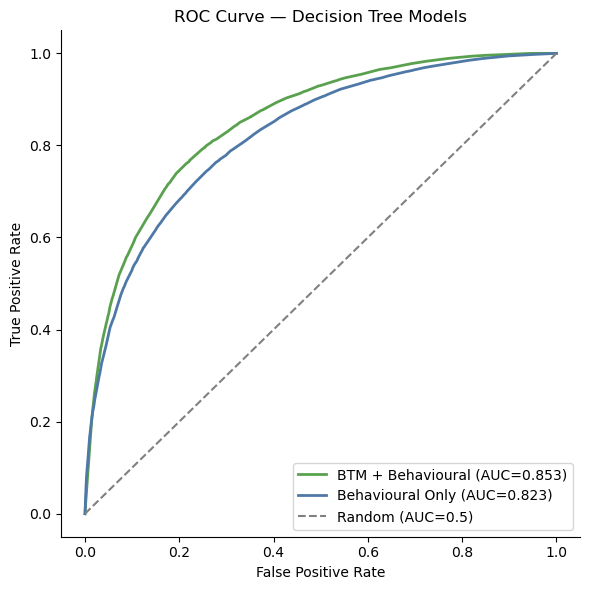

In [324]:
from sklearn.metrics import roc_curve
from sklearn.model_selection import train_test_split

# Single representative train/test split for visualisation only
# (the bar chart above remains the actual evaluation via 10-fold CV)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_full, y_full, test_size=0.2, stratify=y_full, random_state=42
)

dt_full.fit(X_tr, y_tr)
y_prob_full = dt_full.predict_proba(X_te)[:, 1]
fpr_full, tpr_full, _ = roc_curve(y_te, y_prob_full)

X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(
    X_beh, y_beh, test_size=0.2, stratify=y_beh, random_state=42
)
dt_beh.fit(X_tr_b, y_tr_b)
y_prob_beh = dt_beh.predict_proba(X_te_b)[:, 1]
fpr_beh, tpr_beh, _ = roc_curve(y_te_b, y_prob_beh)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr_full, tpr_full, label=f'BTM + Behavioural (AUC={auc_scores_full.mean():.3f})',
        color='#59a14f', linewidth=2)
ax.plot(fpr_beh, tpr_beh, label=f'Behavioural Only (AUC={auc_scores_beh.mean():.3f})',
        color='#4e79a7', linewidth=2)
ax.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Random (AUC=0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Decision Tree Models')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()